# Current version : 10.D (2025-07-23)

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import clear_output
from datetime import datetime
import pickle
from datetime import datetime
import math

pd.options.display.max_rows = 2000

today = datetime.today().strftime('%Y-%m-%d')

mpl.rcParams['svg.fonttype'] = 'none'  # 'none' = keep text as text objects


# Optional: improve SVG precision

mpl.rcParams['svg.hashsalt'] = ''  # consistent hashes for reproducibility

today = datetime.today().strftime('%Y-%m-%d')

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=[ '#009736','#EE2A35',"#3f488aff",
                                                    "#f79a00ff", "#cf1100ff", "#81a5bfff",
                                                    "#f9bd00ff","#547200ff", "#bfd8cdff"]) 

In [2]:
import scanpy as sc

In [3]:
from module.misc import sample_name_import

# name_dir = "circa-SD"
name_dir = "all-samples"

samples, samples_ids = sample_name_import(name_dir)

print(len(samples))
print(samples)

12
['2505-1', '2505-2', '2670-1', '3159-1', '3160-1', '3160-2', '3159-2', '3161-1', '3159-3', '3161-2', '3159-4', '3161-3']


In [4]:
dir_notebook = '../notebook'
# dir_notebook = 'D:\Jupyter_notebook\Xenium_jupyter_notebook'


In [5]:
adata = sc.read_h5ad(f'{dir_notebook}/h5ad/{name_dir}/{name_dir}_final.h5ad.gz')

In [6]:
df = pd.DataFrame(data=adata.X.toarray(), index=adata.obs_names, columns=adata.var_names)
df.shape

from module.xenium_preprocessing import add_annotations

df = add_annotations(adata, df)

In [ ]:
df = pd.read_parquet(f'{dir_notebook}/csv/{name_dir}/{name_dir}_norm_combined.parquet')

In [ ]:
df.groupby(['cell_type_final'])['Ruvbl1'].mean().sort_values()
# plt.scatter(df['Ruvbl1'], df["Ruvbl2"])

In [ ]:
ddf = df[df['Ruvbl1']!=0].groupby('cell_type_final')['Ruvbl1'].count() / df.groupby('cell_type_final')['Ruvbl1'].count()
ddf.sort_values()

In [ ]:
df[df['cell_type_final']=="Microglia"].groupby(['run','region_automap_name'])['cell_type_final'].value_counts().to_csv('data/microglia_dsitrib.csv')

In [ ]:
df.groupby('cell_type_final')['Bdnf'].mean().sort_values()

# List of lists

In [ ]:
### Extract common phase
cell_list_under = ['SMC', 'Sncg_Gaba', 'STR_Gaba', 'COAa_PAA_MEA_Glut', 'OB_STR_CTX_IMN', 'MEA_Glut', 'L5_NP_CTX_Glut',
              'PAL_STR_Gaba_Chol', 'Vip_Gaba', 'Lamp5_Gaba', 'CLA_EPd_CTX_Glut', 'STR_PAL_Gaba', 'L6b_CTX_Glut',
                'Sst_Gaba', 'VLMC', 'PVH_Glut', 'ABC', 'AHN_Glut', 'SCH_Gaba', 'L5_ET_CTX_Glut', 'Choroid', 'Pericyte',
                  'LHA_Glut', 'Pvalb_Gaba', 'Ependymal', 'OPC', 'Microglia', 'L2_3_IT_PIR_ENTl_Glut', 'L6_CT_CTX_Glut',
              'Endothelial', 'STR_D1_Gaba', 'L4_5_IT_CTX_Glut', 'Oligodendrocyte', 'STR_D2_Gaba', 'L6_IT_CTX_Glut', 'Astro_TE']
len(cell_list_under)

cell_list = ['SMC', 'Sncg Gaba', 'STR Gaba', 'COAa PAA MEA Glut', 'OB STR CTX IMN', 'MEA Glut', 'L5 NP CTX Glut',
              'PAL STR Gaba Chol', 'Vip Gaba', 'Lamp5 Gaba', 'CLA EPd CTX Glut', 'STR PAL Gaba', 'L6b CTX Glut',
                'Sst Gaba', 'VLMC', 'PVH Glut', 'ABC', 'AHN Glut', 'SCH Gaba', 'L5 ET CTX Glut', 'Choroid', 'Pericyte',
                  'LHA Glut', 'Pvalb Gaba', 'Ependymal', 'OPC', 'Microglia', 'L2 3 IT PIR ENTl Glut', 'L6 CT CTX Glut',
              'Endothelial', 'STR D1 Gaba', 'L4 5 IT CTX Glut', 'Oligodendrocyte', 'STR D2 Gaba', 'L6 IT CTX Glut', 'Astro TE']

order_list = ['STR D2 Gaba', 'STR D1 Gaba', 'DG Glut', 'CA1 ProS Glut', 'CA2 FC IG Glut', 'CA3 Glut',
               'LSX Gaba', 'CEA Gaba', 'STR PAL Gaba', 'COAa PAA MEA Glut', 'NLOT Glut', 'L2 3 IT PIR ENTl Glut',
                 'CLA EPd CTX Glut', 'L6 CT CTX Glut', 'L6b CTX Glut', 'L5 NP CTX Glut', 'L5 ET CTX Glut',
                   'L2 3 IT RSP Glut', 'L4 5 IT CTX Glut', 'L6 IT CTX Glut', 'Lamp5 Gaba', 'Vip Gaba', 'Sncg Gaba',
                     'Sst Gaba', 'STR Gaba', 'Pvalb Gaba', 'RT ZI Gaba', 'AD Glut', 'PT Glut', 'RE Glut', 'CM Glut',
                       'SMT Glut', 'VP Glut', 'LD Glut', 'VM MD Glut', 'AV Glut', 'MH Glut', 'TRS BAC Glut', 'BAC Glut',
                         'MPO Glut', 'PAL STR Gaba Chol', 'PVT Glut', 'MEA Glut', 'BST Glut', 'SPA Glut', 'AHN Glut',
                           'LHA Glut', 'LH Glut', 'PVH Glut', 'SCH Gaba', 'DG PIR Ex IMN', 'OB STR CTX IMN', 'Microglia',
                             'Endothelial', 'SMC','Pericyte', 'Choroid', 'ABC', 'VLMC', 'Tanycyte', 'Ependymal',
                               'Astro TE', 'OPC', 'Oligodendrocyte']


# Cell Population

In [ ]:
grouped = df.groupby(['run','sample','region_automap_name'])['cell_type_final'].value_counts(dropna=True)
grouped.to_csv('data/cell_count_region.csv')

In [ ]:
import math
df = pd.read_csv('data/cell_count_region.csv')

df = df[df['count'] > 10]

df_nbcells_av = []
df_nbcells_sem = []
df_nbcells_pct = []

all_regions = df['region_automap_name'].unique()
all_celltypes = df['cell_type_final'].unique()

for region in all_regions:
    dat_av = pd.DataFrame()
    dat_sem = pd.DataFrame()
    dat_pct = pd.DataFrame()
    
    for cell in all_celltypes:
        temp_av = df[(df['cell_type_final']== cell) & (df['region_automap_name'] == region)].groupby('run')['count'].mean()
        tempdf = pd.DataFrame(data = {cell : temp_av})
        dat_av = pd.concat([dat_av, tempdf], axis=1)

        temp_percent = df[(df['cell_type_final']== cell)& (df['region_automap_name'] == region) ].groupby('run')['count'].sum() / df[df['region_automap_name'] == region].groupby('run')['count'].sum() * 100
        tempdf = pd.DataFrame(data = {cell : temp_percent}) 
        dat_pct = pd.concat([dat_pct, tempdf], axis=1)  

        temp_sem = df[(df['cell_type_final']== cell) & (df['region_automap_name'] == region)].groupby('run')['count'].std() / df[(df['cell_type_final']== cell) & (df['region_automap_name'] == region)].groupby('run')['count'].count()
        tempdf = pd.DataFrame(data = {cell : temp_sem})
        dat_sem = pd.concat([dat_sem, tempdf], axis=1)
    
    df_nbcells_sem.append(dat_sem)
    df_nbcells_av.append(dat_av)
    df_nbcells_pct.append(dat_pct)

writer = pd.ExcelWriter(f'{dir_notebook}/analysis/{name_dir}/celltype_average.xlsx', engine='xlsxwriter')
for j in range(0,len(all_regions)):
    df_nbcells_av[j].to_excel(writer, sheet_name=all_regions[j], index=False)
writer.close()

writer = pd.ExcelWriter(f'{dir_notebook}/analysis/{name_dir}/celltype_std.xlsx', engine='xlsxwriter')
for j in range(0,len(all_regions)):
    df_nbcells_sem[j].to_excel(writer, sheet_name=all_regions[j], index=False)
writer.close()

writer = pd.ExcelWriter(f'{dir_notebook}/analysis/{name_dir}/celltype_pct.xlsx', engine='xlsxwriter')
for j in range(0,len(all_regions)):
    df_nbcells_pct[j].to_excel(writer, sheet_name=all_regions[j], index=False)
writer.close()

In [ ]:
df_average = pd.read_excel(f'{dir_notebook}/analysis/{name_dir}/celltype_average.xlsx', sheet_name=None)
df_std = pd.read_excel(f'{dir_notebook}/analysis/{name_dir}/celltype_std.xlsx', sheet_name=None)
df_pct = pd.read_excel(f'{dir_notebook}/analysis/{name_dir}/celltype_pct.xlsx', sheet_name=None)

df_average = {key: value for key, value in sorted(df_average.items())}
df_std = {key: value for key, value in sorted(df_std.items())}
df_pct = {key: value for key, value in sorted(df_pct.items())}


df_average.pop('VLMC')
df_average.pop('Ependymal')
df_average.pop('Choroid')
df_average.pop('Tanycyte')

df_std.pop('Tanycyte')
df_std.pop('VLMC')
df_std.pop('Choroid')
df_std.pop('Ependymal')

df_pct.pop('Tanycyte')
df_pct.pop('VLMC')
df_pct.pop('Choroid')
df_pct.pop('Ependymal')
df_pct.pop('AD')

In [ ]:
df_pct['SCH'].sum(axis=0)

In [ ]:
df_pct['SCH']['OPC']

In [ ]:
for key in df_average.keys():
    df_average[key].dropna(axis=1, inplace = True)
    df_std[key] = df_std[key][df_average[key].columns]
    df_average[key].index = ['NS','SD']
    df_std[key].index = ['NS','SD']

    plt.figure(figsize=(5,8))
    plt.barh(y=df_average[key].T.index,
         width=df_average[key].T['NS'],
           height= 0.45, align='edge', label = 'NS',edgecolor='black',
           xerr= df_std[key].T['NS'] 
           )
    plt.barh(y=df_average[key].T.index,
         width=df_average[key].T['SD'],
           height= -0.45, align='edge', label = 'SD',edgecolor='black',
           xerr= df_std[key].T['SD'] )
    plt.xlabel('Average cell number')
    plt.legend()
    plt.title(f'Average cell population : {key}')
    # plt.savefig('Gallery/circa-SD_cellnb.svg')
    clear_output()

In [ ]:
len(df_pct[key])

In [ ]:
for key in df_pct.keys():
    if len(df_pct[key]) == 1:
        continue
    df_pct[key] = df_pct[key][df_pct[key].select_dtypes(np.number).gt(0.5)]
    df_pct[key].dropna(axis=1, inplace = True)
    df_std[key] = df_std[key][df_pct[key].columns]
    df_pct[key].index = ['NS','SD']
    df_std[key].index = ['NS','SD']

    plt.figure(figsize=(5,8))
    plt.barh(y=df_pct[key].T.index,
         width=df_pct[key].T['NS'],
           height= 0.45, align='edge', label = 'NS',edgecolor='black',
           )
    plt.barh(y=df_pct[key].T.index,
         width=df_pct[key].T['SD'],
           height= -0.45, align='edge', label = 'SD',edgecolor='black',
           )
    plt.xlabel('Percentage cells')
    plt.legend()
    plt.title(f'Average cell population : {key}')
    # plt.savefig('Gallery/circa-SD_cellnb.svg')
    clear_output()

# Expressed genes

In [ ]:
df_NS = df[(df['run']=='circa4')]
df_SD = df[(df['run']=='SD1')]
del df

In [ ]:
from module.misc import genes_list

clock_genes = genes_list('panel_5k')
dict_pos = {}

gene_columns = df_SD[clock_genes]
grouped = df_SD.groupby('cell_type_final')


for cell_type, group in grouped:
    gene_presence_pct = group.iloc[:, :-1].mean()
    expressed_genes = gene_presence_pct[gene_presence_pct >= 0.01].index.tolist()
    dict_pos[cell_type] = expressed_genes


In [ ]:
gene_nb = [len(dict_pos[key]) for key in dict_pos.keys()]
gene_nb

In [ ]:
gene_nb.to_csv('../notebook/analysis/circa-SD/SD-genexpression-summary.csv')

# Cycling genes

In [ ]:
import pandas as pd

In [ ]:
df_circa2 = pd.read_excel('../R/Results/2025-07-22_SD1_region/Summary/2025-07-22_SD1_cyc_siggene_analysis.xlsx', sheet_name = 'sig_cyl_gene')
df_circa4 = pd.read_excel('../R/Results/2025-07-22_circa4_region/Summary/2025-07-22_circa4_cyc_siggene_analysis.xlsx', sheet_name = 'sig_cyl_gene')

In [ ]:
circa4_gene = set(df_circa4['CycID'])
circa2_gene = set(df_circa2['CycID'])

In [ ]:
common_genes = circa4_gene.intersection(circa2_gene)

In [ ]:
len(common_genes), len(circa4_gene),len(circa2_gene)

In [ ]:
# library
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Use the venn2 function
venn2(subsets = (1449, 846, 560), set_labels = ('IGM', 'Salk'))
plt.show()


## Polar plot

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample structure: replace this with your real data
# Each row = one observation of a gene at a specific phase
data = pd.DataFrame({
                    'Gene': ['Arntl', 'Clock', 'Cry1', 'Cry2','Npas2', 'Nr1d1', 'Per2', 'Per3','Rorc',
                            'Arntl','Clock','Cry1','Nr1d1','Per1','Per2','Per3','Rorc'
                            ],
                    'Phase': [1.00, 8.38, 15.31, 12.89, 22.56, 8.96,15.30,13.06,16.54,
                              1.00, 3.15, 16.75, 9.02, 11.92, 16.23, 14.17, 17.06
                            ]
                    })

# Convert phase to radians for polar plot
data['Radians'] = data['Phase'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data['Gene'].unique()
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data['Gene'].map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data['Gene'].map(gene_colors)

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data['Gene'] == gene]
    ax.scatter(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene], s=40)

ax.set_yticks(range(1, len(gene_order) + 1))
ax.set_yticklabels(gene_order)
ax.set_ylim(0.5, len(gene_order) + 0.5)
ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

plt.title('Clock Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left", title='Gene')

plt.tight_layout()
plt.show()

## Cell type spe polar

In [ ]:
import pandas as pd

dir_sum = '../R/Results/2025-06-25_circa4_celltype/Summary'

df = pd.read_excel(f'{dir_sum}/2025-06-25_circa4_cyc_siggene_by_celltype.xlsx', sheet_name=None, usecols=['CycID', 'meta2d_phase'])

In [ ]:
clockgenelist=['Arntl', 'Clock', 'Cry1', 'Cry2', 'Npas2', 'Nr1d1', 'Per1', 'Per2', 'Per3', 'Rora', 'Rorb', 'Rorc']
dataset = pd.DataFrame()
for key in df.keys():
    subdf = df[key].filter(['CycID', 'meta2d_phase'], axis=1)
    subdf = subdf[subdf['CycID'].isin(clockgenelist)]
    dataset = pd.concat([dataset, subdf])

In [ ]:
all_celltype_CG = dict(zip(dataset['CycID'], dataset['meta2d_phase']))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample structure: replace this with your real data
# Each row = one observation of a gene at a specific phase
data = pd.DataFrame({
                    'Gene': dataset['CycID'],
                    'Phase': dataset['meta2d_phase']
                    })
data = data.sort_values('Gene')

# Convert phase to radians for polar plot
data['Radians'] = data['Phase'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data['Gene'].unique()
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data['Gene'].map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data['Gene'].map(gene_colors)

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data['Gene'] == gene]
    ax.scatter(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene], s=40)

# # for gene in gene_order:
# gene = 'Per1'
# subset = data[data['Gene'] == gene]
# ax.hist(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene])  


# ax.set_yticks(range(1, len(gene_order) + 1))
# ax.set_yticklabels(gene_order)
# ax.set_ylim(0.5, len(gene_order) + 0.5)
ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

plt.title('Clock Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left")


plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Each row = one observation of a gene at a specific phase
data = pd.DataFrame({
                    'Gene': dataset['CycID'],
                    'Phase': dataset['meta2d_phase']
                    })
data = data.sort_values('Gene')

# Convert phase to radians for polar plot
data['Radians'] = data['Phase'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data['Gene'].unique()
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data['Gene'].map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data['Gene'].map(gene_colors)

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data['Gene'] == gene]
    ax.scatter(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene], s=40)

# # for gene in gene_order:
# gene = 'Per1'
# subset = data[data['Gene'] == gene]
# ax.hist(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene])  


# ax.set_yticks(range(1, len(gene_order) + 1))
# ax.set_yticklabels(gene_order)
# ax.set_ylim(0.5, len(gene_order) + 0.5)
ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

plt.title('Clock Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left")


plt.tight_layout()
plt.show()

## Histo polar plot

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
run_namdate_NS = "2025-08-08_circa4"
run_namdate_SD = "2025-08-09_SD1"
run_type = 'celltype'

dir_sum_NS = f'../R/Results/{run_namdate_NS}_{run_type}/Summary'
dir_sum_SD = f'../R/Results/{run_namdate_SD}_{run_type}/Summary'


df_all_NS = pd.read_excel(f'{dir_sum_NS}/{run_namdate_NS}_cyc_siggene_analysis.xlsx', sheet_name=None)
df_all_SD = pd.read_excel(f'{dir_sum_SD}/{run_namdate_SD}_cyc_siggene_analysis.xlsx', sheet_name=None)


# cycling_summary = pd.read_csv(f'{dir_sum}/{run_namdate}_cycling_gene_count_by_celltype.csv', index_col='cycling_gene_count')

In [ ]:
common_regions = set(df_all_NS.keys()).intersection(df_all_SD.keys())

for idx, celltype in enumerate(common_regions):
# for idx, celltype in enumerate(["Astro TE"]):
    # Data preparation
    df_NS = pd.DataFrame(data=zip(df_all_NS[celltype]['CycID'], df_all_NS[celltype]['meta2d_phase']))
    df_NS.columns = ['Gene','Phase']
    df_NS['Radians'] = df_NS['Phase'] / 24 * 2 * np.pi

    df_SD = pd.DataFrame(data=zip(df_all_SD[celltype]['CycID'], df_all_SD[celltype]['meta2d_phase']))
    df_SD.columns = ['Gene','Phase']
    df_SD['Radians'] = df_SD['Phase'] / 24 * 2 * np.pi

    # Plot
    plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)
    ax.set_theta_direction(-1)
    ax.set_theta_offset(np.pi / 2.0)
    ax.grid(True)

    ax.hist(df_NS['Radians'], bins = 24, alpha = 0.75, label = "NS")
    ax.hist(df_SD['Radians'], bins = 24, alpha = 0.75, label = "SD")

    ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
    ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

    plt.title(f'Genes Phase in {celltype}')
    plt.legend()
    plt.savefig(f'Gallery/{today}/polarplot/polar_gene_{celltype}.svg')
    plt.show()
    plt.close()


### Histo polar in region/gene panel

In [ ]:
import pandas as pd
from module.misc import genes_list

gene_list = genes_list('mitochondria')
region = 'SCH'
df_all = pd.read_excel(f'../R/Results/2025-08-11_circa4_celltype_and_region/Summary/2025-08-11_circa4_cyc_siggene_analysis.xlsx', sheet_name=region)

# # Data preparation
# df = pd.DataFrame(data=zip(df_all['CycID'], df_all['meta2d_phase']))
# df.columns = ['Gene','Phase']
# df = df[df['Gene'].isin(gene_list)]
# df['Radians'] = df['Phase'] / 24 * 2 * np.pi

# # Plot
# plt.figure(figsize=(6,6))
# ax = plt.subplot(111, polar=True)
# ax.set_theta_direction(-1)
# ax.set_theta_offset(np.pi / 2.0)
# ax.grid(True)

# ax.hist(df['Radians'], bins = 24,
#         #  color = 'green'
#          )

# ax.set_xticks(np.linspace(0, 2 * np.pi, 12, endpoint=False))
# ax.set_xticklabels(['0', '2', '4','6', '8', '10','12','14', '16','18', '20','22'])

# plt.title(f'Genes Phase in {region}')
# # plt.savefig(f'Gallery/circa2/polar_gene_{region}.svg')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from module.misc import genes_list

region = 'SCH'
df_all = pd.read_excel(f'data/SCH_cyc_analysis.xlsx', sheet_name='sig_cyl_gene')
gene_list = genes_list('mitochondria')

# Data preparation
df = pd.DataFrame(data=zip(df_all['CycID'], df_all['meta2d_phase']))
df.columns = ['Gene','Phase']
df = df[df['Gene'].isin(gene_list)]
df['Radians'] = df['Phase'] / 24 * 2 * np.pi

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

ax.hist(df['Radians'], bins = 24,
        #  color = 'green'
         )

ax.set_xticks(np.linspace(0, 2 * np.pi, 12, endpoint=False))
ax.set_xticklabels(['0', '2', '4','6', '8', '10','12','14', '16','18', '20','22'])

plt.title(f'Genes Phase in {region}')
# plt.savefig(f'Gallery/circa2/polar_gene_{region}.svg')

## Phase comparison

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
run_namdate_1 = "2025-08-08_circa4"
run_namdate_2 = "2025-08-09_SD1"
run_type = 'celltype'
cell_type_plot = 'SCH Gaba'

dir_sum_1 = f'../R/Results/{run_namdate_1}_{run_type}/Summary'
dir_sum_2 = f'../R/Results/{run_namdate_2}_{run_type}/Summary'

df_all_NS = pd.read_excel(f'{dir_sum_1}/{run_namdate_1}_cyc_siggene_analysis.xlsx', sheet_name=cell_type_plot)
df_all_SD = pd.read_excel(f'{dir_sum_2}/{run_namdate_2}_cyc_siggene_analysis.xlsx', sheet_name=cell_type_plot)

In [ ]:
from module.misc import genes_list

gene_list_plot = genes_list("clock")

dataset_NS = pd.DataFrame()

subdf_all_NS = df_all_NS.filter(['CycID', 'meta2d_phase'], axis=1)
subdf_all_NS = subdf_all_NS[subdf_all_NS['CycID'].isin(gene_list_plot)]
dataset_NS = pd.concat([dataset_NS, subdf_all_NS])

dataset_SD = pd.DataFrame()
subdf_all_SD = df_all_SD.filter(['CycID', 'meta2d_phase'], axis=1)
subdf_all_SD = subdf_all_SD[subdf_all_SD['CycID'].isin(gene_list_plot)]
dataset_SD = pd.concat([dataset_SD, subdf_all_SD])

In [ ]:
data = pd.DataFrame(index=gene_list_plot)

In [ ]:
all_celltype_NS = dict(zip(dataset_NS['CycID'], dataset_NS['meta2d_phase']))
all_celltype_SD = dict(zip(dataset_SD['CycID'], dataset_SD['meta2d_phase']))

In [ ]:
data['NS'] = data.index.map(all_celltype_NS)
data['SD'] = data.index.map(all_celltype_SD)
# data.dropna(inplace= True)
data['Gene'] = data.index
data['Diff'] = data['NS'] - data['SD']
data = data.sort_values(by='NS')

In [ ]:

data['NS2'] = data['NS']
data['SD2'] = data['SD']

# for n in range(len(data)):
#     if data.iloc[n,data.columns.get_loc("Diff")] > 12:
#         if data.iloc[n,data.columns.get_loc("NS")] < data.iloc[n,data.columns.get_loc("SD")]:
#             data.iloc[n,data.columns.get_loc("NS2")] = data.iloc[n,data.columns.get_loc("NS")] + 24
#         else:
#             data.iloc[n,data.columns.get_loc("NS2")] = data.iloc[n,data.columns.get_loc("SD")] + 24
#     else:
#         data.iloc[n,data.columns.get_loc("NS2")] = data.iloc[n,data.columns.get_loc("NS")]
#         data.iloc[n,data.columns.get_loc("SD")] = data.iloc[n,data.columns.get_loc("SD")]
thres = 12

for n in range(len(data)):
    if (abs(data.iloc[n,data.columns.get_loc("Diff")]) >= thres):
        if (data.iloc[n,data.columns.get_loc("SD")] > data.iloc[n,data.columns.get_loc("NS")]):
            data.iloc[n,data.columns.get_loc("SD2")] = data.iloc[n,data.columns.get_loc("SD")]-24
        elif (data.iloc[n,data.columns.get_loc("SD")] < data.iloc[n,data.columns.get_loc("NS")]):
            data.iloc[n,data.columns.get_loc("SD2")] = data.iloc[n,data.columns.get_loc("SD")] + 24
    else:
        data.iloc[n,data.columns.get_loc("SD2")] = data.iloc[n,data.columns.get_loc("SD")]
        data.iloc[n,data.columns.get_loc("NS2")] = data.iloc[n,data.columns.get_loc("NS")]

# data = data.sort_values(by="Diff", ascending=False)
data = data.sort_index()

In [ ]:
data

In [ ]:
# Convert phase to radians for polar plot
data['Radians_NS'] = data['NS'] / 24 * 2 * np.pi
data['Radians_SD'] = data['SD'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data.index
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data.index.map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data.index.map(gene_colors)

# Plot
plt.figure(figsize=(5,5))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data.index == gene]
    ax.scatter(subset['Radians_NS'], subset['Radius'], label=gene, color=gene_colors[gene], s=40, edgecolors='black')
    ax.scatter(subset['Radians_SD'], subset['Radius'], color=gene_colors[gene], alpha = 0.5, s=40)

ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])
ax.set_ylabel(ylabel=None)
plt.title('Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left")


plt.tight_layout()
plt.show()

In [ ]:
# Color palette
import seaborn as sns
gene_order = data.index
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data.index.map(gene_colors)

In [ ]:
# data = data[0:20]

In [ ]:
plt.figure(figsize=(3,4))
ax =ax = plt.subplot()

for n in range(len(data)):
    ax.hlines(y=n, xmin=data.iloc[n,data.columns.get_loc("NS2")], xmax=data.iloc[n,data.columns.get_loc("SD2")], linestyles='dashed', color = 'black')
    ax.scatter(x=data.iloc[n,data.columns.get_loc("NS2")],y=n,
               color = data.iloc[n,data.columns.get_loc("Color")],
                 edgecolors='black', label = data.index.values[n])
    ax.scatter(x=data.iloc[n,data.columns.get_loc("SD2")], y=n, color = data.iloc[n,data.columns.get_loc("Color")])
ax.set_xlim(0,24)
ax.set_ylim(-0.25, len(data)-0.75)
ax.set_xticks([0,4,8,12,16,20,24])
ax.set_xlabel('ZT')
ax.set_yticks(ticks = range(len(data)),labels = data['Gene'])
ax.vlines(x = [0,12,24], ymin=0, ymax=len(data), color = 'darkgrey', linestyles='dashed')
ax.invert_yaxis()
plt.tight_layout()

# plt.legend()

## Barplot

In [ ]:
df_gen_NS = pd.read_csv('../notebook/analysis/circa-SD/NS-genexpression-summary.csv', index_col="Celltype")
df_gen_SD = pd.read_csv('../notebook/analysis/circa-SD/SD-genexpression-summary.csv', index_col="Celltype")

In [ ]:
df_gen_NS.to_csv('../notebook/analysis/circa-SD/NS-genexpression-summary.csv')
df_gen_SD.to_csv('../notebook/analysis/circa-SD/SD-genexpression-summary.csv')

In [ ]:
run_namdate_1 = "2025-08-08_circa4"
run_namdate_2 = "2025-08-09_SD1"
run_type = 'celltype'

dir_sum_1 = f'../R/Results/{run_namdate_1}_{run_type}/Summary'
dir_sum_2 = f'../R/Results/{run_namdate_2}_{run_type}/Summary'

cycling_summary_1 = pd.read_csv(f'{dir_sum_1}/{run_namdate_1}_cycling_gene_per_group.csv', index_col='celltype')
cycling_summary_2 = pd.read_csv(f'{dir_sum_2}/{run_namdate_2}_cycling_gene_per_group.csv', index_col='celltype')

In [ ]:
NS_dict = dict(zip(cycling_summary_1.index,cycling_summary_1['cycling_gene_count']))
SD_dict = dict(zip(cycling_summary_2.index,cycling_summary_2['cycling_gene_count']))

df_gen_NS['Cycling_pval'] = df_gen_NS.index.map(NS_dict)
df_gen_SD['Cycling_pval'] = df_gen_SD.index.map(SD_dict)

In [ ]:
df_NS = pd.read_excel(f'{dir_sum_1}/{run_namdate_1}_cyc_siggene_analysis.xlsx', sheet_name=None, usecols=['CycID','meta2d_BH.Q'])
df_SD = pd.read_excel(f'{dir_sum_2}/{run_namdate_2}_cyc_siggene_analysis.xlsx', sheet_name=None, usecols=['CycID','meta2d_BH.Q'])


common = {}
sum_com = {}
common_cells = set(df_NS.keys()).intersection(set(df_SD.keys()))

for key in common_cells:
    # df_NS[key] = df_NS[key][df_NS[key]['meta2d_BH.Q']>=0.05]
    # df_SD[key] = df_SD[key][df_SD[key]['meta2d_BH.Q']>=0.05]
    common[key] = df_NS[key][df_NS[key]['CycID'].isin(df_SD[key]['CycID'])]
    sum_com[key] = len(common[key])

sum_com_df = pd.DataFrame({'Gene': sum_com.keys(),
                    'Common': sum_com.values()})
sum_com_df.index = sum_com_df['Gene']

In [ ]:
sum_com_dict = dict(zip(sum_com_df['Gene'],sum_com_df['Common']))
df_gen_NS['Common_pval'] = df_gen_NS.index.map(sum_com_dict)
df_gen_SD['Common_pval'] = df_gen_SD.index.map(sum_com_dict)


In [ ]:
df_NS_BH_nb = [len(df_NS[key]) for key in df_NS.keys()]
ddf_NS_BH_nb = pd.DataFrame(data ={'Expressed_genes':df_NS_BH_nb}, index = df_NS.keys())

df_SD_BH_nb = [len(df_SD[key]) for key in df_SD.keys()]
ddf_SD_BH_nb = pd.DataFrame(data ={'Expressed_genes':df_SD_BH_nb}, index = df_SD.keys())

# NS_BH_dict = dict(zip(ddf_NS_BH_nb.index, ddf_NS_BH_nb['Expressed_genes']))
# df_gen_NS['Cycling_BH'] = df_gen_NS.index.map(NS_BH_dict)

# SD_BH_dict = dict(zip(ddf_SD_BH_nb.index, ddf_SD_BH_nb['Expressed_genes']))
# df_gen_SD['Cycling_BH'] = df_gen_SD.index.map(SD_BH_dict)

In [ ]:
cycling_summary_1 = cycling_summary_1[cycling_summary_1.index.isin(cycling_summary_2.index)].sort_values(by='cycling_gene_count')
cycling_summary_2 = cycling_summary_2[cycling_summary_2.index.isin(cycling_summary_1.index)]

In [ ]:
len(cycling_summary_1), len(cycling_summary_2)

In [ ]:
df_gen_NS.sort_values(by='Common_pval',inplace=True)
df_gen_NS.drop('CEA Gaba',axis=0, inplace=True)
# df_gen_NS.dropna(axis=0, inplace= True)
# df_gen_SD.dropna(axis=0, inplace= True)

In [ ]:
len(df_gen_NS), len(df_gen_SD)

In [ ]:
which_has_more_CG = {}

for gene in df_gen_NS.index:
    if df_gen_NS['Cycling_pval'][gene] < df_gen_SD['Cycling_pval'][gene]:
        which_has_more_CG[gene] = 0
    else:
        which_has_more_CG[gene] = 1

which_has_more_CG.keys()


In [ ]:
fig, ax = plt.subplots(figsize = (5,8))
# ax.barh(y = df_gen_NS.index, width = -df_gen_NS['Count'], label = 'Expressed', color = 'None', edgecolor ='black')
# ax.barh(y = df_gen_SD.index, width = df_gen_SD['Count'], color = 'None', edgecolor = 'black')

ax.barh(y = df_gen_NS.index, width = -df_gen_NS['Cycling_pval'], edgecolor = 'black', label = 'Cycling NS', align = "center")
ax.barh(y = df_gen_SD.index, width= df_gen_SD['Cycling_pval'], edgecolor = 'black', label = 'Cycling SD', align = "center")
ax.barh(y = df_gen_NS.index, width=df_gen_NS['Common_pval'], label = 'Common', color = 'black', align = "center")
ax.barh(y = df_gen_SD.index, width=-df_gen_SD['Common_pval'], color = 'black', align = "center")
ax.vlines(x=0,ymin=-1,ymax=len(df_gen_NS), color = "black")
ax.set_ylim(-0.5,len(df_gen_NS))
ax.set_xlim(-2000,2000)
ax.grid(axis="x")
ax.set_axisbelow(b=True)
ax.legend(loc='lower left')
ax.set_title('Cycling genes in normal and disrupted sleep')

for n, gene in enumerate(which_has_more_CG.keys()):
    if which_has_more_CG[gene] > 0:
        ax.text(x = -df_gen_NS['Cycling_pval'][gene]-75, y = n-0.5, s = '#', weight = 'bold', ha = "center")
    else:
        ax.text(x = df_gen_SD['Cycling_pval'][gene]+75, y = n-0.5, s = '#',weight = 'bold', ha = "center")


plt.savefig(f'Gallery/{today}/Cycling_genes_overview.svg', dpi=300, format ="svg", transparent = True)

In [ ]:
which_has_more_CG

In [ ]:
order_list =[
        "Oligodendrocyte","Microglia","Endothelial","SMC","Pericyte","VLMC","ABC",
        "Ependymal", "OB STR CTX IMN","OPC","Astro TE", "SCH Gaba","PVH Glut","AHN Glut","PAL STR Gaba Chol","MEA Glut","LHA Glut",
    "Pvalb Gaba","STR Gaba","Sst Gaba","Sncg Gaba","Vip Gaba","Lamp5 Gaba","L6 IT CTX Glut","L4 5 IT CTX Glut","L5 ET CTX Glut",
    "L5 NP CTX Glut","L6b CTX Glut","L6 CT CTX Glut","L2 3 PIR ENTl Glut","L2 3 IT PIR ENTl Glut","COAa PAA MEA Glut",
    "DG Glut","STR PAL Gaba","STR D1 Gaba","STR D2 Gaba",]


cycling_summary_1_sort = cycling_summary_1.reindex(order_list)
cycling_summary_1_sort.dropna(axis=0, inplace=True)
cycling_summary_1_sort = cycling_summary_1_sort.reindex(sorted(cycling_summary_1_sort.columns), axis=1)
cycling_summary_1_sort.head(2)

In [ ]:
df_gen_NS_sort =df_gen_NS.reindex(order_list)
df_gen_SD_sort = df_gen_SD.reindex(order_list)
df_gen_NS_sort.dropna(axis=0, inplace= True)
df_gen_SD_sort.dropna(axis=0, inplace= True)
cycling_summary_2_sort = cycling_summary_2.reindex(order_list)
cycling_summary_2_sort.dropna(axis=0, inplace=True)

In [ ]:
len(df_gen_NS_sort),len(df_gen_SD_sort),len(cycling_summary_1_sort),len(cycling_summary_2_sort)

In [ ]:
fig, ax = plt.subplots(figsize = (5,8))
# ax.barh(y = df_gen_NS.index, width = -df_gen_NS['Count'], label = 'Expressed', color = 'None', edgecolor ='black')
# ax.barh(y = df_gen_SD.index, width = df_gen_SD['Count'], color = 'None', edgecolor = 'black')
ax.barh(y = df_gen_NS_sort.index, width = -df_gen_NS_sort['Cycling_pval'], edgecolor = 'black', label = 'Cycling NS')
ax.barh(y = df_gen_SD_sort.index, width= df_gen_SD_sort['Cycling_pval'], edgecolor = 'black', label = 'Cycling SD')
ax.barh(y = df_gen_NS_sort.index, width=df_gen_NS_sort['Common_pval'], label = 'Common', color = 'black')
ax.barh(y = df_gen_SD_sort.index, width=-df_gen_SD_sort['Common_pval'], color = 'black')
ax.vlines(x=0,ymin=-1,ymax=len(df_gen_NS_sort), color = "black")
ax.set_ylim(-0.5,len(df_gen_NS_sort))
ax.legend(loc='lower left')
ax.set_title('Cycling genes in normal and disrupted sleep')
plt.savefig(f'Gallery/{today}/Cycling_genes_overview_dendro.svg',dpi=300)

## Cycling genes correlation

In [ ]:
run_namdate = "2025-07-21_circa4"
run_type = 'celltype'

dir_sum = f'../R/Results/{run_namdate}_{run_type}/Summary'

df_all = pd.read_excel(f'{dir_sum}/{run_namdate}_cyc_siggene_analysis.xlsx', sheet_name=None)

In [ ]:
from module.misc import genes_list

gens = genes_list('panel_5k')

df_genes = pd.DataFrame(data={"Gene" : gens}, index= gens)


for key in df_all.keys():
    df_genes[key] = np.zeros(len(df_genes))

    for gene in df_all[key]['CycID'].unique():
        df_genes.loc[gene,key] +=1



In [ ]:
df_genes.drop('Gene',axis=1, inplace=True)

In [ ]:
# order_list = ['SMC', 'Sncg Gaba', 'STR Gaba', 'PAL STR Gaba Chol',
#        'L2 3 PIR ENTl Glut', 'MEA Glut', 'OB STR CTX IMN', 'L5 NP CTX Glut',
#        'COAa PAA MEA Glut', 'Vip Gaba', 'Lamp5 Gaba', 'DG Glut', 'ABC',
#        'STR PAL Gaba', 'PVH Glut', 'L6b CTX Glut', 'AHN Glut', 'SCH Gaba',
#        'Sst Gaba', 'VLMC', 'L5 ET CTX Glut', 'Pericyte', 'LHA Glut',
#        'Ependymal', 'Pvalb Gaba', 'Microglia', 'OPC', 'L2 3 IT PIR ENTl Glut',
#        'STR D1 Gaba', 'L6 CT CTX Glut', 'Endothelial', 'Oligodendrocyte',
#        'L4 5 IT CTX Glut', 'STR D2 Gaba', 'L6 IT CTX Glut', 'Astro TE']

order_list =[
        "Oligodendrocyte","Microglia","Endothelial","SMC","Pericyte","VLMC","ABC",
        "Ependymal", "OB STR CTX IMN","OPC","Astro TE", "SCH Gaba","PVH Glut","AHN Glut","PAL STR Gaba Chol","MEA Glut","LHA Glut",
    "Pvalb Gaba","STR Gaba","Sst Gaba","Sncg Gaba","Vip Gaba","Lamp5 Gaba","L6 IT CTX Glut","L4 5 IT CTX Glut","L5 ET CTX Glut",
    "L5 NP CTX Glut","L6b CTX Glut","L6 CT CTX Glut","L2 3 PIR ENTl Glut","L2 3 IT PIR ENTl Glut","COAa PAA MEA Glut",
    "DG Glut","STR PAL Gaba","STR D1 Gaba","STR D2 Gaba",]

df_genes_sort = df_genes.loc[:, order_list]

In [ ]:
df_corr = df_genes_sort.corr(method='kendall')

In [ ]:
df_corr.min().min()

In [ ]:
import seaborn as sns

sns.clustermap(df_corr, cmap = 'Blues', vmin=0,vmax=1,
                col_cluster=False,row_cluster=False, cbar = False, cbar_pos=None,figsize=(12, 12),
                )
plt.title('Correlation of cycling genes in NS')
plt.savefig(f'Gallery/{today}/NS_corr_cyclinggenes_ordernbcycgenes.svg',dpi=300)

## Phase Comparison plotting

### Summary table

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from module.misc import genes_list
import numpy as np
import math

cg_list = genes_list('clock')

In [ ]:
dataframe_cg_cycling = pd.DataFrame(data = {"Gene" : cg_list,
                                            "Expressed": np.zeros(len(cg_list)),
                                            "NS_Cyc" : np.zeros(len(cg_list)),
                                            "SD_Cyc" : np.zeros(len(cg_list)),
                                            "Common_Cyc" : np.zeros(len(cg_list)),
                                            "Same_phase" : np.zeros(len(cg_list)),
                                            "Same Amplitude" :np.zeros(len(cg_list)),
                                            "Same Mesor" : np.zeros(len(cg_list))
                                             },
                                              index = cg_list)
dataframe_cg_cycling.sample()

In [ ]:
cell_list = ['SMC', 'Sncg Gaba', 'STR Gaba', 'COAa PAA MEA Glut', 'OB STR CTX IMN', 'MEA Glut', 'L5 NP CTX Glut',
              'PAL STR Gaba Chol', 'Vip Gaba', 'Lamp5 Gaba', 'CLA EPd CTX Glut', 'STR PAL Gaba', 'L6b CTX Glut',
                'Sst Gaba', 'VLMC', 'PVH Glut', 'ABC', 'AHN Glut', 'SCH Gaba', 'L5 ET CTX Glut', 'Choroid', 'Pericyte',
                  'LHA Glut', 'Pvalb Gaba', 'Ependymal', 'OPC', 'Microglia', 'L2 3 IT PIR ENTl Glut', 'L6 CT CTX Glut',
              'Endothelial', 'STR D1 Gaba', 'L4 5 IT CTX Glut', 'Oligodendrocyte', 'STR D2 Gaba', 'L6 IT CTX Glut', 'Astro TE']

In [ ]:
### Extract expression
for cell in cell_list:
    df_expressed_NS = pd.read_csv(f'../R/data/gene_list_SD1/{cell}.csv')
    gene_exp_NS = set(df_expressed_NS[df_expressed_NS['0'].isin(cg_list)]['0'])
    df_expressed_SD = pd.read_csv(f'../R/data/gene_list_circa4/{cell}.csv')
    gene_exp_SD = set(df_expressed_SD[df_expressed_SD['0'].isin(cg_list)]['0'])
    common_exp =  gene_exp_NS.intersection(gene_exp_SD)

    if len(common_exp) > 0:
        for gene in common_exp:
            dataframe_cg_cycling.loc[gene, "Expressed"] +=1

In [ ]:
### Extract common cycling

df_cycling_NS = pd.read_excel(f'../R/Results/2025-08-08_circa4_celltype/Summary/2025-08-08_circa4_cyc_siggene_analysis.xlsx', sheet_name = None)
df_cycling_SD = pd.read_excel(f'../R/Results/2025-08-09_SD1_celltype/Summary/2025-08-09_SD1_cyc_siggene_analysis.xlsx', sheet_name = None)

for cell in cell_list:
    gene_cyc_NS = set(df_cycling_NS[cell][df_cycling_NS[cell]['CycID'].isin(cg_list)]['CycID'])
    if len(gene_cyc_NS) > 0:
        for gene in gene_cyc_NS:
            dataframe_cg_cycling.loc[gene, "NS_Cyc"] +=1
    gene_cyc_SD = set(df_cycling_SD[cell][df_cycling_SD[cell]['CycID'].isin(cg_list)]['CycID'])
    if len(gene_cyc_SD) > 0:
        for gene in gene_cyc_SD:
            dataframe_cg_cycling.loc[gene, "SD_Cyc"] +=1
    common_cyc = gene_cyc_NS.intersection(gene_cyc_SD)
    if len(common_cyc) > 0:
        for gene in common_cyc:
            dataframe_cg_cycling.loc[gene, "Common_Cyc"] +=1

In [ ]:
### Extract common phase
cell_list_under = ['SMC', 'Sncg_Gaba', 'STR_Gaba', 'COAa_PAA_MEA_Glut', 'OB_STR_CTX_IMN', 'MEA_Glut', 'L5_NP_CTX_Glut',
              'PAL_STR_Gaba_Chol', 'Vip_Gaba', 'Lamp5_Gaba', 'CLA_EPd_CTX_Glut', 'STR_PAL_Gaba', 'L6b_CTX_Glut',
                'Sst_Gaba', 'VLMC', 'PVH_Glut', 'ABC', 'AHN_Glut', 'SCH_Gaba', 'L5_ET_CTX_Glut', 'Choroid', 'Pericyte',
                  'LHA_Glut', 'Pvalb_Gaba', 'Ependymal', 'OPC', 'Microglia', 'L2_3_IT_PIR_ENTl_Glut', 'L6_CT_CTX_Glut',
              'Endothelial', 'STR_D1_Gaba', 'L4_5_IT_CTX_Glut', 'Oligodendrocyte', 'STR_D2_Gaba', 'L6_IT_CTX_Glut', 'Astro_TE']
len(cell_list_under)

In [ ]:
for cell in cell_list_under:
    df_phase_NS = pd.read_csv(f'../R/Results/CircaCompare_Results/{cell}_circacompare_results.csv')
    common_phase = set(df_phase_NS[(df_phase_NS['gene'].isin(cg_list)) & (df_phase_NS['P-value for difference in phase'] > 0.05)]['gene'])
    if len(common_phase) > 0:
            for gene in common_phase:
                dataframe_cg_cycling.loc[gene, "Same_phase"] +=1

    df_phase_NS = pd.read_csv(f'../R/Results/CircaCompare_Results/{cell}_circacompare_results.csv')
    common_phase = set(df_phase_NS[(df_phase_NS['gene'].isin(cg_list)) & (df_phase_NS['P-value for amplitude difference'] > 0.05)]['gene'])
    if len(common_phase) > 0:
            for gene in common_phase:
                dataframe_cg_cycling.loc[gene, "Same Amplitude"] +=1

    df_phase_NS = pd.read_csv(f'../R/Results/CircaCompare_Results/{cell}_circacompare_results.csv')
    common_phase = set(df_phase_NS[(df_phase_NS['gene'].isin(cg_list)) & (df_phase_NS['P-value for mesor difference'] > 0.05)]['gene'])
    if len(common_phase) > 0:
            for gene in common_phase:
                dataframe_cg_cycling.loc[gene, "Same Mesor"] +=1

In [ ]:
dataframe_cg_cycling.sort_values(by='Common_Cyc')

In [ ]:
dataframe_cg_cycling.sort_values(by='Same_phase',inplace=True, ascending=False)

In [ ]:
w1 = dataframe_cg_cycling['Expressed'][0:25] - dataframe_cg_cycling['Common_Cyc'][0:25] 
w2 = dataframe_cg_cycling['Common_Cyc'][0:25] -  dataframe_cg_cycling["Same_phase"][0:25]
w3 = dataframe_cg_cycling["Same_phase"][0:25]

_, ax = plt.subplots(1,2, figsize = (4,6), sharey= True)

ax[1].barh(y = dataframe_cg_cycling.index[0:25], width=w1, left = 0, label = "Expressed NS/SD", color = "#3f488aff", edgecolor ="black")
ax[1].barh(y = dataframe_cg_cycling.index[0:25], width=w2, left = w1, label = "Cycling NS/SD", color= "#f79a00ff", edgecolor ="black")
ax[1].barh(y = dataframe_cg_cycling.index[0:25], width=w3, left = w1+w2, label = "In phase", color = "#81a5bfff", edgecolor ="black")
ax[1].set_xticks(ticks = [0,12,24,36])
ax[1].set_xlim(0,36)
ax[1].set_xlabel('Number of celltypes')
ax[1].legend(loc = 'best', bbox_to_anchor = (0.99,0.5))
                                          

ax[0].barh(y=dataframe_cg_cycling.index[0:25], width = dataframe_cg_cycling['NS_Cyc'][0:25], height=0.4, align="edge", edgecolor ="black",label = "Cycling NS")
ax[0].barh(y=dataframe_cg_cycling.index[0:25], width = dataframe_cg_cycling['SD_Cyc'][0:25], height=-0.4, align="edge", edgecolor ="black", label = "Cycling SD")
ax[0].barh(y=dataframe_cg_cycling.index[0:25], width = dataframe_cg_cycling['Expressed'][0:25], height=-0.8, align="center",fill = None, edgecolor ="black", label = "Expressed")

ax[0].legend(loc = 'upper left', bbox_to_anchor = (2.2,1))
ax[0].set_xticks(ticks = [0,12,24,36])
ax[0].set_xlim(0,36)
ax[0].set_xlabel('Number of celltypes')

plt.ylim(-0.5,24.5)

# plt.savefig(f"Gallery/{today}/Summary_cycling_phase_compare_top-inphase.svg", format='svg',transparent = True)

### Create database

#### Celltype

In [ ]:
dict_all_cycling = {}

for idx, cell in enumerate(cell_list_under):
    df_cyc_NS = pd.read_excel(f"../R/Results/2025-08-08_circa4_celltype/Raw/{cell}_cyc_analysis.xlsx", sheet_name="meta")
    df_cyc_NS.index = df_cyc_NS['CycID']
    df_cyc_filter_NS = pd.read_excel(f"../R/Results/2025-08-08_circa4_celltype/Raw/{cell}_cyc_analysis.xlsx", sheet_name="sig_cyl_gene")
    df_cyc_filter_NS.index = df_cyc_filter_NS['CycID']
    df_cyc_SD = pd.read_excel(f"../R/Results/2025-08-09_SD1_celltype/Raw/{cell}_cyc_analysis.xlsx", sheet_name="meta")
    df_cyc_SD.index = df_cyc_SD['CycID']
    df_cyc_filter_SD = pd.read_excel(f"../R/Results/2025-08-09_SD1_celltype/Raw/{cell}_cyc_analysis.xlsx", sheet_name="sig_cyl_gene")
    df_cyc_filter_SD.index = df_cyc_filter_SD['CycID']
    df_circacompare = pd.read_csv(f'../R/Results/CircaCompare_Results/{cell}_circacompare_results.csv')
    df_circacompare.index = df_circacompare['gene']

    df_DEG = pd.read_excel('../notebook/analysis/circa-SD/foldchanges/celltype/DEG_celltype_no-filter.xlsx', sheet_name=cell_list[idx])
    df_DEG.index = df_DEG['names']
    # df_DEG = df_DEG[df_DEG['group'] == "SD1"]

    df_DEG_filter = df_DEG[(df_DEG['pvals_adj'] < 0.05)
                                 & (df_DEG['pct_nz_group'] > 0.0)
                                 & (df_DEG['pct_nz_reference'] > 0)
                                 & (abs(df_DEG['logfoldchanges']) > 0.26)
                                 & (df_DEG['mean_count'] >= 0.01)
                                 & (df_DEG['group'] == "SD1")
                                 ]


    dict_all_cycling[cell] = {"NS_cyc" : df_cyc_NS,
                              "NS_cyc_filter" : df_cyc_filter_NS, 
                              "SD_cyc" : df_cyc_SD,
                              "SD_cyc_filter" : df_cyc_filter_SD,
                              "CircaCompare" : df_circacompare,
                              "DEG" : df_DEG,
                              "DEG_filter" : df_DEG_filter}


#### Celltype in regions

In [ ]:
import os
import pandas as pd

regions_DEG = ['AHN','AMY','AV','CM','CTX','HIPP', 'HY','LD','LHA','LH','LSX', 'MEA', 'MH','NLOT','PVH','PVT','RE', 'RT ZI','SCH','SMT','STR','TH','TRS','VLMC','VM' 'MD', 'VP','WM']
regions_Cyc = ["AHN", "AMY", "CTX", "LHA", "PVH","SCH", "STR"]

dict_all_cellinreg = {}



directory_DEG = '../notebook/analysis/circa-SD/foldchanges/celltype_in_region/'
directory_NS = '../R/Results/2025-08-11_SD1_celltype_and_region/Raw/'
directory_SF = '../R/Results/2025-08-11_circa4_celltype_and_region/Raw/'


all_regions_NS = os.listdir(directory_NS)
all_regions_NS =  [region for region in all_regions_NS if region.split('_')[-1] == 'analysis.xlsx' ]

all_regions_SF = os.listdir(directory_SF)
all_regions_SF =  [region for region in all_regions_SF if region.split('_')[-1] == 'analysis.xlsx' ]

all_regions_DEG = os.listdir(directory_DEG)
all_regions_DEG =  [region for region in all_regions_DEG if region.split('_')[-1] == 'DEG.xlsx' ]

region = 'SCH'

dict_all_cellinreg[region] = {}

for cell in cell_list_under:
    dict_all_cellinreg[region][cell] = {}
    if f'{cell}_in_{region}_cyc_analysis.xlsx' in all_regions_NS:
        dict_all_cellinreg[region][cell]['NS_cyc_filter'] = pd.read_excel(f'{directory_NS}/{cell}_in_{region}_cyc_analysis.xlsx', sheet_name = 'sig_cyl_gene')
        dict_all_cellinreg[region][cell]['NS_cyc'] = pd.read_excel(f'{directory_NS}/{cell}_in_{region}_cyc_analysis.xlsx', sheet_name = 'meta')
    if f'{cell}_in_{region}_cyc_analysis.xlsx' in all_regions_SF:
        dict_all_cellinreg[region][cell]['SF_cyc_filter'] = pd.read_excel(f'{directory_SF}/{cell}_in_{region}_cyc_analysis.xlsx', sheet_name = 'sig_cyl_gene')
        dict_all_cellinreg[region][cell]['SF_cyc'] = pd.read_excel(f'{directory_SF}/{cell}_in_{region}_cyc_analysis.xlsx', sheet_name = 'meta')
    
    


In [ ]:
dict_all_cellinreg['SCH']['Astro_TE'].keys()

In [ ]:
all_regions_NS

In [ ]:
# for idx, cell in enumerate(cell_list_under):
#     df_cyc_NS = pd.read_excel(f"../R/Results/2025-08-08_circa4_celltype/Raw/{cell}_cyc_analysis.xlsx", sheet_name="meta")
#     df_cyc_NS.index = df_cyc_NS['CycID']
#     df_cyc_filter_NS = pd.read_excel(f"../R/Results/2025-08-08_circa4_celltype/Raw/{cell}_cyc_analysis.xlsx", sheet_name="sig_cyl_gene")
#     df_cyc_filter_NS.index = df_cyc_filter_NS['CycID']
#     df_cyc_SD = pd.read_excel(f"../R/Results/2025-08-09_SD1_celltype/Raw/{cell}_cyc_analysis.xlsx", sheet_name="meta")
#     df_cyc_SD.index = df_cyc_SD['CycID']
#     df_cyc_filter_SD = pd.read_excel(f"../R/Results/2025-08-09_SD1_celltype/Raw/{cell}_cyc_analysis.xlsx", sheet_name="sig_cyl_gene")
#     df_cyc_filter_SD.index = df_cyc_filter_SD['CycID']
#     df_circacompare = pd.read_csv(f'../R/Results/CircaCompare_Results/{cell}_circacompare_results.csv')
#     df_circacompare.index = df_circacompare['gene']

#     df_DEG = pd.read_excel('../notebook/analysis/circa-SD/foldchanges/celltype/DEG_celltype_no-filter.xlsx', sheet_name=cell_list[idx])
#     df_DEG.index = df_DEG['names']
#     # df_DEG = df_DEG[df_DEG['group'] == "SD1"]

#     df_DEG_filter = df_DEG[(df_DEG['pvals_adj'] < 0.05)
#                                  & (df_DEG['pct_nz_group'] > 0.0)
#                                  & (df_DEG['pct_nz_reference'] > 0)
#                                  & (abs(df_DEG['logfoldchanges']) > 0.26)
#                                  & (df_DEG['mean_count'] >= 0.01)
#                                  & (df_DEG['group'] == "SD1")
#                                  ]


#     dict_all_cellinreg[cell] = {"NS_cyc" : df_cyc_NS,
#                               "NS_cyc_filter" : df_cyc_filter_NS, 
#                               "SD_cyc" : df_cyc_SD,
#                               "SD_cyc_filter" : df_cyc_filter_SD,
#                               "CircaCompare" : df_circacompare,
#                               "DEG" : df_DEG,
#                               "DEG_filter" : df_DEG_filter}


In [ ]:
df = pd.read_excel('../R/Results/2025-08-11_SD1_celltype_and_region/')

#### Save and Load Database

In [ ]:
with open(f"{dir_notebook}/analysis/circa-SD/cycling_genes_database.pickle", "wb") as handle:
    pickle.dump(dict_all_cycling, handle, protocol=-1)


In [ ]:
import pickle
with open(f"{dir_notebook}/analysis/circa-SD/cycling_genes_database.pickle", "rb") as handle:
    dict_all_cycling = pickle.load(handle)

### Plot cycling gene phase comparison

In [ ]:
cg_to_plot = 'Srebf2'

In [ ]:

df_temp = pd.DataFrame(data = {"Celltype" : cell_list_under,
                               "CircaCompare_pval" : np.zeros(len(cell_list_under)),
                               "CircaCompare_NS_Phase": np.zeros(len(cell_list_under)),
                               "CircaCompare_SD_Phase" : np.zeros(len(cell_list_under)),
                               "CircaCompare_phase_diff" : np.zeros(len(cell_list_under)),
                               "Cyc_NS_filt_phase" : np.zeros(len(cell_list_under)),
                               "Cyc_SD_filt_phase" : np.zeros(len(cell_list_under)),
                               "Cyc_NS_phase" : np.zeros(len(cell_list_under)),
                               "Cyc_SD_phase" : np.zeros(len(cell_list_under)),
                               }, index = cell_list_under)

for cell in cell_list_under:
    if len(dict_all_cycling[cell]['CircaCompare'][dict_all_cycling[cell]['CircaCompare']['gene']==cg_to_plot]) != 0:
        df_temp.loc[cell, "CircaCompare_pval"] = dict_all_cycling[cell]['CircaCompare']['P-value for difference in phase'][cg_to_plot]
        df_temp.loc[cell, "CircaCompare_NS_Phase"] = dict_all_cycling[cell]['CircaCompare']['circa4 peak time hours'][cg_to_plot]
        df_temp.loc[cell, "CircaCompare_SD_Phase"] = dict_all_cycling[cell]['CircaCompare']['SD1 peak time hours'][cg_to_plot]
        df_temp.loc[cell, "CircaCompare_phase_diff"] = dict_all_cycling[cell]['CircaCompare']["Phase difference estimate"][cg_to_plot]
    else:
        df_temp.loc[cell, "CircaCompare_pval"] = 1
        df_temp.loc[cell, "CircaCompare_NS_Phase"] = df_temp.loc[cell, "CircaCompare_SD_Phase"] = -1
        df_temp.loc[cell, "CircaCompare_phase_diff"] = 0
    
    if len(dict_all_cycling[cell]['NS_cyc_filter'][dict_all_cycling[cell]['NS_cyc_filter']['CycID']==cg_to_plot]) != 0:
        df_temp.loc[cell, "Cyc_NS_filt_phase"] = dict_all_cycling[cell]['NS_cyc_filter']['meta2d_phase'][cg_to_plot]
    else:
        df_temp.loc[cell, "Cyc_NS_filt_phase"] = -1

    if len(dict_all_cycling[cell]['SD_cyc_filter'][dict_all_cycling[cell]['SD_cyc_filter']['CycID']==cg_to_plot]) != 0:
        df_temp.loc[cell, "Cyc_SD_filt_phase"] = dict_all_cycling[cell]['SD_cyc_filter']['meta2d_phase'][cg_to_plot]
    else:
        df_temp.loc[cell, "Cyc_SD_filt_phase"] = -1

    if len(dict_all_cycling[cell]['SD_cyc_filter'][dict_all_cycling[cell]['SD_cyc_filter']['CycID']==cg_to_plot]) != 0:
        df_temp.loc[cell, "Cyc_SD_phase"] = dict_all_cycling[cell]['SD_cyc']['meta2d_phase'][cg_to_plot]
    else:
        df_temp.loc[cell, "Cyc_SD_phase"] = -1

    if len(dict_all_cycling[cell]['NS_cyc_filter'][dict_all_cycling[cell]['NS_cyc_filter']['CycID']==cg_to_plot]) != 0:
        df_temp.loc[cell, "Cyc_NS_phase"] = dict_all_cycling[cell]['NS_cyc']['meta2d_phase'][cg_to_plot]
    else:
        df_temp.loc[cell, "Cyc_NS_phase"] = -1


df_temp['Circa_diff'] = df_temp['CircaCompare_NS_Phase'] -  df_temp['CircaCompare_SD_Phase']

In [ ]:
plt.figure(figsize=(4,8))
plt.xticks([0,4,8,12,16,20,24])
plt.xlim(0,24)
plt.scatter(y = df_temp['Celltype'], x =df_temp['CircaCompare_NS_Phase'], color = "green", alpha = 0.8, edgecolor="black", label ="NS")
plt.scatter(y = df_temp['Celltype'], x =df_temp['CircaCompare_SD_Phase'], color = "red", alpha = 0.8, edgecolor="black", marker="v", label ="SD")

for cell in df_temp['Celltype']:
    if (0 < df_temp.loc[cell,'CircaCompare_pval'] <= 0.05) & (df_temp.loc[cell,'CircaCompare_NS_Phase'] < df_temp.loc[cell,'CircaCompare_SD_Phase']) & (abs(math.trunc(df_temp.loc[cell,'CircaCompare_phase_diff'])) != abs(math.trunc(df_temp.loc[cell,'Circa_diff']))):
        plt.scatter(y = df_temp.loc[cell,'Celltype'], x =df_temp.loc[cell,'CircaCompare_NS_Phase']+24, color = "green", alpha = 0.8, edgecolor="black", label ="NS")
        plt.hlines(y=df_temp.loc[cell,'Celltype'], xmax = df_temp.loc[cell,'CircaCompare_NS_Phase']+24, xmin = df_temp.loc[cell,'CircaCompare_SD_Phase'], color = 'black', linestyles="dashed")
        x_av = ((df_temp['CircaCompare_NS_Phase'][cell]+24) + df_temp['CircaCompare_SD_Phase'][cell]) / 2
        plt.text(x = x_av , y = cell, s = "*", weight = 'bold')
        plt.xlim(0,36)
        plt.xticks([0,4,8,12,16,20,24,28,32,36])
    elif (0 < df_temp.loc[cell,'CircaCompare_pval'] <= 0.05) & (df_temp.loc[cell,'CircaCompare_NS_Phase'] > df_temp.loc[cell,'CircaCompare_SD_Phase']) & (abs(math.trunc(df_temp.loc[cell,'CircaCompare_phase_diff'])) != abs(math.trunc(df_temp.loc[cell,'Circa_diff']))):
        plt.scatter(y = df_temp.loc[cell,'Celltype'], x =df_temp.loc[cell,'CircaCompare_SD_Phase']+24, color = "red", marker="v", alpha = 0.8, edgecolor="black", label ="NS")
        plt.hlines(y=df_temp.loc[cell,'Celltype'], xmax = df_temp.loc[cell,'CircaCompare_SD_Phase']+24, xmin = df_temp.loc[cell,'CircaCompare_NS_Phase'], color = 'black', linestyles="dashed")
        x_av = ((df_temp['CircaCompare_NS_Phase'][cell]+24) + df_temp['CircaCompare_SD_Phase'][cell]) / 2
        plt.text(x = x_av , y = cell, s = "*", weight = 'bold')
        plt.xlim(0,36)
        plt.xticks([0,4,8,12,16,20,24,28,32,36])
    elif((0 < df_temp.loc[cell,'CircaCompare_pval'] <= 0.05) & (abs(math.trunc(df_temp.loc[cell,'CircaCompare_phase_diff'])) == abs(math.trunc(df_temp.loc[cell,'Circa_diff'])))):
        plt.hlines(y=df_temp.loc[cell,'Celltype'], xmin = df_temp.loc[cell,'CircaCompare_NS_Phase'], xmax = df_temp.loc[cell,'CircaCompare_SD_Phase'], color = 'black', linestyles="dashed")
        x_av = (df_temp['CircaCompare_NS_Phase'][cell] + df_temp['CircaCompare_SD_Phase'][cell]) / 2
        plt.text(x = x_av , y = cell, s = "*", weight = 'bold')

for cell in df_temp['Celltype']:
    if (df_temp.loc[cell,'CircaCompare_pval'] == 1):
        plt.scatter(y = df_temp.loc[cell,'Celltype'], x =df_temp.loc[cell,'Cyc_NS_filt_phase'], color = "green", alpha = 0.5)
        plt.scatter(y = df_temp.loc[cell,'Celltype'], x =df_temp.loc[cell,'Cyc_SD_filt_phase'], color = "red", alpha = 0.5, marker="v")




plt.ylim(-0.5,36)
plt.vlines(x=[12,24,36],ymin=0,ymax=36, color = "lightgrey", linestyles="dashed")
plt.title(cg_to_plot)
# plt.legend()
# plt.yticks(ticks = range(0,36), label=cell_list_under)
plt.savefig(f'Gallery/{today}/CG_all-celltype_{cg_to_plot}.svg', format = 'svg',transparent = True)

# Test Squidpy

## Data Import

In [ ]:
import squidpy as sq
import pandas as pd
import scanpy as sc
import numpy as np

In [ ]:
dir_notebook = '/media/volume/volume_spatial/hugo/notebook'
name_dir = "circa-SD"
adata = sc.read_h5ad(f'{dir_notebook}/h5ad/{name_dir}/{name_dir}_final.h5ad.gz')
# adata_bis = sc.read_h5ad(r'..\..\h5ad\run3-SC\run3-SC_clusters.h5ad.gz')


In [ ]:
# adata = adata[adata.obs['sample'] == 'SD1-ZT01']
adata = adata[adata.obs['run'] == "circa4"] 
# adata_bis = adata_bis[adata_bis.obs['sample'] == '3161-3']
# adata = adata[adata.obs['region_automap_name']=='SCH']
# adata.obsm['spatial'] = adata.obsm['coord_xy']

In [ ]:
adata

In [ ]:
adata.obsm['spatial'] = adata_bis.obsm['spatial'] 

In [ ]:
adata

In [ ]:
adata_sub = adata[adata.obs["region_automap_name"]=='CTX']

In [ ]:
adata_sub.obs.sample()

## Spatial correlation

In [ ]:
sq.gr.spatial_neighbors(adata_sub)

In [ ]:
sq.gr.nhood_enrichment(adata_sub, cluster_key="cell_type_final")

In [ ]:
sq.pl.nhood_enrichment(adata_sub, cluster_key="cell_type_final")

## Moran

In [ ]:
sq.gr.spatial_neighbors(adata_sub, coord_type="generic", delaunay=True)
sq.gr.spatial_autocorr(
    adata_sub,
    mode="moran",
    n_perms=100,
    n_jobs=5,
)
adata_sub.uns["moranI"].head(15)

In [ ]:
sq.pl.spatial_scatter(
    adata_sub,
    library_id="spatial",
    color=[
        "Gfap",
        "Vip",
        "Arc"
    ],
    shape=None,
    size=2,
    img=False,
)

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Tlr1",
        "Tlr6",
        "Tlr3"
    ],
    shape=None,
    size=2,
    img=False,
)

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Gpr88",
        "Ppp3r1",
        "Foxj1"
    ],
    shape=None,
    size=2,
    img=False,
)

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Sostdc1",
    ],
    shape=None,
    size=2,
    img=False,
)

## LigRec

In [ ]:
adata_sub.raw = adata_sub.copy()

In [ ]:
adata_sub.obs['cell_type_final'].value_counts(normalize=False)

In [ ]:
sc.pp.subsample(adata_sub, fraction = 0.1) ### Will automatically replace adata_sub everytime you run it. Be carefull

In [ ]:
adata_sub

In [ ]:
sq.gr.ligrec(adata_sub,
             "cell_type_final",
            #  clusters = ("L6 CT CTX Glut", "Vip Gaba"),
             use_raw=True,
             complex_policy = "all",
            #  threshold = 0.5,
             corr_method = 'fdr_bh',
             alpha =0.01,
             n_jobs = 2,
             n_perms = 10000)

In [ ]:
adata_sub.uns['cell_type_final_ligrec'].keys()

In [ ]:
adata_sub.uns['cell_type_final_ligrec']['pvalues'].to_csv('data/LigRec_CTX_circa4_pvalues.csv')
#[('Oligodendrocyte','Oligodendrocyte')]

In [ ]:
sq.pl.ligrec(adata_sub,
            source_groups="Sst Gaba",
            # target_groups= "Microglia",
            cluster_key='cell_type_final',
            remove_nonsig_interactions=True,
            alpha = 0.001,
            dendrogram= None,
            pvalue_threshold = 0.001,
            means_range = (0.5,1.9)
             )


# DEG

## Data import

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
cell_nb = pd.read_csv(f'{dir_notebook}/analysis/{name_dir}/summary_cell_number.csv')
cell_nb

In [ ]:
from module.misc import cell_class

dict_temp = cell_class()

cell_nb['cell_class'] = cell_nb['cell_type_final'].apply(lambda x: dict_temp[x] if x in dict_temp.keys() else "Neuron")
cell_nb

In [ ]:
param = 'Genotype'
group1 = "WT"
group2 = 'APP'

plt.figure(figsize=(15,5))
plt.bar(x=cell_nb['cell_type_final'][cell_nb[param]==group1],
         height=cell_nb[cell_nb[param]==group1]['count'],
           width = 0.5, align='edge', edgecolor ='black')
plt.bar(x=cell_nb['cell_type_final'][cell_nb[param]==group2],
         height=cell_nb[cell_nb[param]==group2]['count'],
           width = -0.5, align='edge', edgecolor ='black')
plt.xticks(ticks=cell_nb['cell_type_final'][cell_nb[param]==group2], rotation=90)
plt.yscale('log')
plt.savefig(f'Gallery/{name_dir}_cellnb.svg')

## Cell pop hierarchical order

In [7]:
df = df[~(df['cell_type_final'] == 'Undefined')]
df = df[~(df['cell_type_final'] == 'AD Glut')]

In [8]:
cell_pop = df.groupby(['cell_type_final','Genotype'])["ZT"].count()
cell_pop.head()

cell_type_final  Genotype
APN Glut         APP         1435
                 WT          1159
ARH GABA         APP          465
                 WT           402
AV Glut          APP         4005
Name: ZT, dtype: int64

In [ ]:
cell_pop = pd.read_csv('../notebook/analysis/circa-SD/circa-SD_cellpop.csv')
# circa_pct = pd.read_csv('../notebook/analysis/circa-SD/circa-SD_circa-percent.csv')

In [9]:
cell_pop = pd.DataFrame(data = {"cell_type_final" : cell_pop.index,
                                "count" : cell_pop.values})
# cell_pop.rename(columns={"ZT" : "count"})


In [10]:
from module.misc import cell_class

cell_pop[['celltype','genotype']] = cell_pop['cell_type_final'].apply(pd.Series)

class_dict = cell_class()
cell_pop['cell_class'] = 'Neuron'
cell_pop['cell_class'] = cell_pop['celltype'].map(class_dict)
cell_pop['cell_class'] = cell_pop['cell_class'].fillna('Neuron')

cell_pop

,cell_type_final,count,celltype,genotype,cell_class
0,"(APN Glut, APP)",1435,APN Glut,APP,Neuron
1,"(APN Glut, WT)",1159,APN Glut,WT,Neuron
2,"(ARH GABA, APP)",465,ARH GABA,APP,Neuron
3,"(ARH GABA, WT)",402,ARH GABA,WT,Neuron
4,"(AV Glut, APP)",4005,AV Glut,APP,Neuron
5,"(AV Glut, WT)",142,AV Glut,WT,Neuron
6,"(Astro NT, APP)",40845,Astro NT,APP,Glial
7,"(Astro NT, WT)",26280,Astro NT,WT,Glial
8,"(Astro TE, APP)",66313,Astro TE,APP,Glial
9,"(Astro TE, WT)",42500,Astro TE,WT,Glial


In [ ]:
# cell_pop['cell_type_final'] = cell_pop.index
cell_pop.sort_values(by='cell_type_final', inplace=True, ignore_index=True)
# circa_pct.sort_values(by='cell_type_final', inplace=True, ignore_index=True)


In [ ]:
from module.misc import genes_list

clock_genes = genes_list('brain_panel')
df_CG = df.filter(clock_genes, axis = 1)

In [ ]:
df_CG['cell_type_final'] = df['cell_type_final']
df_CG.sample() 

In [ ]:
grouped = df.groupby('cell_type_final')[clock_genes].mean()

In [11]:
order_list = ['STR D2 Gaba', 'STR D1 Gaba', 'DG Glut', 'CA1 ProS Glut', 'CA2 FC IG Glut', 'CA3 Glut',
               'LSX Gaba', 'CEA Gaba', 'STR PAL Gaba', 'COAa PAA MEA Glut', 'NLOT Glut', 'L2 3 IT PIR ENTl Glut',
                 'CLA EPd CTX Glut', 'L6 CT CTX Glut', 'L6b CTX Glut', 'L5 NP CTX Glut', 'L5 ET CTX Glut',
                   'L2 3 IT RSP Glut', 'L4 5 IT CTX Glut', 'L6 IT CTX Glut', 'Lamp5 Gaba', 'Vip Gaba', 'Sncg Gaba',
                     'Sst Gaba', 'STR Gaba', 'Pvalb Gaba', 'RT ZI Gaba', 'AD Glut', 'PT Glut', 'RE Glut', 'CM Glut',
                       'SMT Glut', 'VP Glut', 'LD Glut', 'VM MD Glut', 'AV Glut', 'MH Glut', 'TRS BAC Glut', 'BAC Glut',
                         'MPO Glut', 'PAL STR Gaba Chol', 'PVT Glut', 'MEA Glut', 'BST Glut', 'SPA Glut', 'AHN Glut',
                           'LHA Glut', 'LH Glut', 'PVH Glut', 'SCH Gaba', 'DG PIR Ex IMN', 'OB STR CTX IMN', 'Microglia',
                             'Endothelial', 'SMC','Pericyte', 'Choroid', 'ABC', 'VLMC', 'Tanycyte', 'Ependymal',
                               'Astro TE', 'OPC', 'Oligodendrocyte']

order_list = ['Oligodendrocyte', 'OPC', 'Astro NT', 'Astro TE', 'Ependymal', 'Pineal Glut', 'Tanycyte', 'CHOR', 'VLMC', 'Endothelial', 'Pericyte', 'Microglia', 'CA1 ProS Glut', 'CA2 FC IG Glut', 'CA3 Glut', 'DG Glut', 'L23 PIR ENTl Glut', 'MEA Glut', 'LA Glut', 'NLOT Glut', 'L23 CTX Glut', 'L23 RSP Glut', 'L4 CTX Glut', 'L6 CTX Glut', 'L5 CTX Glut', 'SUB ProS Glut', 'L6b CTX Glut', 'AD Glut', 'AV Glut', 'TH Glut', 'SN Dopa', 'LHA Glut', 'MB Glut', 'PAG Glut', 'HY Glut', 'LH Glut', 'VMH Glut', 'MM Glut', 'PVT Glut', 'PF Glut', 'APN Glut', 'SC Glut', 'MH Glut', 'BST Glut', 'LSX Gaba', 'SCH Gaba', 'Sst Gaba', 'MEA Gaba', 'BST Gaba', 'HY GABA', 'ARH GABA', 'Lamp5 Gaba', 'Vip Gaba', 'STR Gaba', 'STRv PAL Gaba', 'LGv Gaba', 'PRT Gaba', 'SC Gaba', 'ZI Gaba', 'SN Gaba', 'RT ZI GABA', 'Pvalb Gaba', 'STR D1D2 Gaba']



# cell_pop["Celltype_order"] = pd.Categorical(cell_pop["cell_type_final"], categories=order_list, ordered = True)
cell_pop["Celltype_order"] = pd.Categorical(cell_pop["celltype"], categories=order_list, ordered = True)

cell_pop.sort_values('Celltype_order', inplace= True)

# grouped_sort = grouped.reindex(order_list)
# grouped_sort

In [30]:
cell_pop

,cell_type_final,count,celltype,genotype,cell_class,Celltype_order
75,"(Oligodendrocyte, WT)",96083,Oligodendrocyte,WT,Glial,Oligodendrocyte
74,"(Oligodendrocyte, APP)",150764,Oligodendrocyte,APP,Glial,Oligodendrocyte
73,"(OPC, WT)",18646,OPC,WT,Glial,OPC
72,"(OPC, APP)",30855,OPC,APP,Glial,OPC
6,"(Astro NT, APP)",40845,Astro NT,APP,Glial,Astro NT
7,"(Astro NT, WT)",26280,Astro NT,WT,Glial,Astro NT
9,"(Astro TE, WT)",42500,Astro TE,WT,Glial,Astro TE
8,"(Astro TE, APP)",66313,Astro TE,APP,Glial,Astro TE
26,"(Ependymal, APP)",13111,Ependymal,APP,Ependymal,Ependymal
27,"(Ependymal, WT)",10257,Ependymal,WT,Ependymal,Ependymal


In [ ]:
### One bar for all
import seaborn as sns

plt.figure(figsize=(2,10))

plt.barh(y=cell_pop['cell_type_final'],
         width=cell_pop['count'],
           height = 0.8, align='edge', edgecolor ='black')
plt.xscale('log')
plt.grid(axis='x')
plt.ylim(-1,len(cell_pop))


plt.savefig(f'Gallery/{today}/{name_dir}_cellpop.svg', dpi=300, format = "svg",transparent = True)

(-1.0, 62.0)

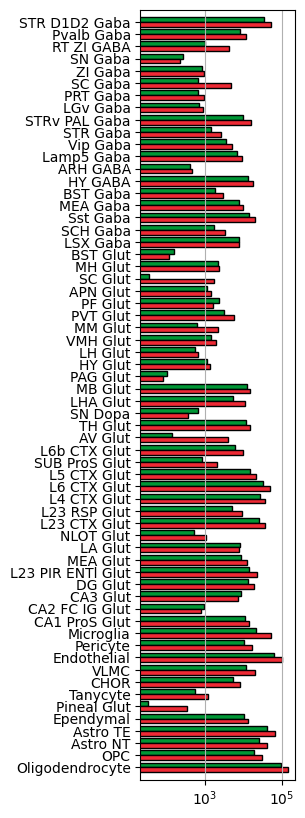

In [15]:
### One bar epr genotype
import seaborn as sns

temp = cell_pop#[cell_pop['cell_class']=="Neuron"]
# temp.sort_values(by="count", inplace = True)

plt.figure(figsize=(2,10))

plt.barh(y=temp[temp['genotype']=='WT']['celltype'],
         width=temp[temp['genotype']=='WT']['count'],
           height = 0.4, align='edge', edgecolor ='black')
plt.barh(y=temp[temp['genotype']=='APP']['celltype'],
         width=temp[temp['genotype']=='APP']['count'],
           height = -0.4, align='edge', edgecolor ='black')
plt.xscale('log')
plt.grid(axis='x')
plt.ylim(-1,len(temp)/2)


# plt.savefig(f'Gallery/{today}/{name_dir}_cellpop.svg', dpi=300, format = "svg",transparent = True)

## Data import DEG celltype

In [ ]:
# dir_notebook = 'D:\\Jupyter_notebook\\Xenium_jupyter_notebook'

control = "WT"
test = "APP"

df_all = pd.read_excel(f'{dir_notebook}/analysis/{name_dir}/foldchanges/celltype/DEG_celltype_no-filter.xlsx', sheet_name=None)
df_expressed = {}
for key in df_all.keys():
    if control in df_all[key]["group"].unique():
        df_all[key] = df_all[key][df_all[key]['group'] == test]
    df_expressed[key] = df_all[key][
            (df_all[key]['pct_nz_group']>0.05) &
          (df_all[key]['mean_count']>= 0.01)
          ]
    df_all[key].index = df_all[key]['names']

In [ ]:
df_filter = pd.read_excel('../notebook/analysis/circa-SD/DEG_celltype_filter.xlsx', sheet_name=None)

for key in df_filter.keys():
    df_filter[key] = df_filter[key][df_filter[key]['group'] == 'SD1']
    df_filter[key].index = df_filter[key]['names']

In [ ]:
### Alternative filtering
df_filter = {}
for key in df_all.keys():
    df_filter[key] = df_all[key][(df_all[key]['pvals_adj'] < 0.05)
                                 & (df_all[key]['pct_nz_group'] > 0.05)
                                 & (df_all[key]['pct_nz_reference'] > 0.05)
                                 & (abs(df_all[key]['logfoldchanges']) > 0.26)
                                 & (df_all[key]['mean_count'] >= 0.01)
                                 ]
# df_filter['SCH'].sort_values(by='logfoldchanges')

### All DEG

In [ ]:
list_of_DEG = []
for key in df_filter:
    list_temp = list(df_filter[key]['names'])
    list_of_DEG.extend(list_temp)

In [ ]:
unique_gene = set(list_of_DEG)
count_dict = {}
for gene in unique_gene:
    count_dict[gene] = list_of_DEG.count(gene)

In [ ]:
df = pd.DataFrame(data ={"Gene": list(unique_gene)})

In [ ]:
df['count'] = df['Gene'].map(count_dict)
df.sort_values(by='count', inplace = True, ascending = False)
df.shape

In [ ]:
df.sort_values(by='count')

In [ ]:
mean_exp = pd.DataFrame(columns=['Gene','mean_count'])
a = 0
for key in df_filter.keys():
    for gene in df_filter[key]['names']:
        temp_count = df_filter[key]['mean_count'][gene]
        mean_exp.loc[a] = [gene, temp_count]
        a +=1

In [ ]:
mean_exp = mean_exp.groupby('Gene')['mean_count'].mean()
mean_exp.head()

In [ ]:
dict_mean_exp = dict(zip(mean_exp.index,mean_exp.values))

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2,1, figsize=(3,8))
ax = ax.flatten()
ax[1].barh(y=df['Gene'][0:20], height=0.8, width=df['count'][0:20], edgecolor = 'black')
# plt.hist(x=df['count'])
sns.histplot(df['count'], element="bars", cumulative= False, fill= True, common_norm=False,kde = True,
             stat='frequency', ax=ax[0])
plt.xlabel('Number of celltypes')
# plt.yscale("log")

In [ ]:
from module.misc import cell_class
dict_cellclass = cell_class()

list_of_celltype = [key for key in df_filter.keys()]
df_celltype = pd.DataFrame(data = {'Celltype' : list_of_celltype})
df_celltype['Cellclass'] = df_celltype['Celltype'].apply(lambda x: dict_cellclass[x] if x in dict_cellclass.keys() else "Neuron")
df_celltype.sample(5)

In [ ]:
from module.misc import genes_list

gene_index = genes_list('panel_5k')

matrix = pd.DataFrame(data = {'Neuron':np.zeros(5006),
                              "Glial" : np.zeros(5006),
                              'Vascular': np.zeros(5006),
                              'Ependymal': np.zeros(5006)}, index = gene_index)

class_list = df_celltype.groupby('Cellclass')['Celltype'].unique()

for nb, class_ in enumerate(class_list):
    class_for_matrix = class_list.index[nb]
    for celltype_ in class_:
        list_temp = list(df_filter[celltype_]['names'])
        for gene in list_temp:
            matrix.loc[gene,class_for_matrix] += 1


matrix['total'] = matrix.sum(axis=1)
matrix.sort_values(by='total', ascending = False, inplace= True)

In [ ]:
y1 = matrix['Vascular'][0:25]
y2 = matrix['Ependymal'][0:25]
y3 = matrix['Glial'][0:25]
y4 = matrix['Neuron'][0:25]

import seaborn as sns
fig, ax = plt.subplots(2,1, figsize=(3,10))
ax = ax.flatten()

# plt.hist(x=df['count'])
sns.histplot(matrix['total'], element="bars", cumulative= False, fill= True, bins=50,
             common_norm=False, kde = True,
             stat='count', ax=ax[0])

# ax[0].hist(x=matrix['total'])


ax[1].barh(y=matrix.index[0:25], height=0.8, width=y1, edgecolor = 'black', label = "Vascular")
ax[1].barh(y=matrix.index[0:25], height=0.8, width=y2, left = y1,  edgecolor = 'black', label = "Ependymal")
ax[1].barh(y=matrix.index[0:25], height=0.8, width=y3, left = y1+y2,  edgecolor = 'black',label = "Glial")
ax[1].barh(y=matrix.index[0:25], height=0.8, width=y4, left = y1+y2+y3,  edgecolor = 'black', label = "Neuron")
ax[1].legend()
ax[1].set_xlabel('Number of celltypes')

# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y1b, edgecolor = 'black', label = "Vascular")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y2b, left = y1b,  edgecolor = 'black', label = "Ependymal")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y3b, left = y1b+y2b,  edgecolor = 'black',label = "Glial")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y4b, left = y1b+y2b+y3b,  edgecolor = 'black', label = "Neuron")
# ax[2].legend()
# ax[2].set_xlabel('Number of celltypes')

plt.savefig(f'Gallery/{today}/DEG_distribution.svg', dpi = 300)



In [ ]:
matrix_bis = matrix[matrix['total']!=0]
matrix_bis['mean_count'] = matrix_bis.index.map(dict_mean_exp)
matrix_bis

In [ ]:
y1 = matrix_bis['Vascular'][0:25]
y2 = matrix_bis['Ependymal'][0:25]
y3 = matrix_bis['Glial'][0:25]
y4 = matrix_bis['Neuron'][0:25]

y1b = matrix_bis['Vascular'][-25:-1]
y2b = matrix_bis['Ependymal'][-25:-1]
y3b = matrix_bis['Glial'][-25:-1]
y4b = matrix_bis['Neuron'][-25:-1]




import seaborn as sns
fig, ax = plt.subplots(2,1, figsize=(3,10))
ax = ax.flatten()

# plt.hist(x=df['count'])
sns.histplot(matrix_bis['total'], element="bars", cumulative= False, fill= True, bins=50,
             common_norm=False, kde = True,
             stat='count', ax=ax[0])

# ax[0].hist(x=matrix['total'])


ax[1].barh(y=matrix_bis.index[0:25], height=0.8, width=y1, edgecolor = 'black', label = "Vascular")
ax[1].barh(y=matrix_bis.index[0:25], height=0.8, width=y2, left = y1,  edgecolor = 'black', label = "Ependymal")
ax[1].barh(y=matrix_bis.index[0:25], height=0.8, width=y3, left = y1+y2,  edgecolor = 'black',label = "Glial")
ax[1].barh(y=matrix_bis.index[0:25], height=0.8, width=y4, left = y1+y2+y3,  edgecolor = 'black', label = "Neuron")
ax[1].legend()
ax[1].set_xlabel('Number of celltypes')

# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y1b, edgecolor = 'black', label = "Vascular")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y2b, left = y1b,  edgecolor = 'black', label = "Ependymal")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y3b, left = y1b+y2b,  edgecolor = 'black',label = "Glial")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y4b, left = y1b+y2b+y3b,  edgecolor = 'black', label = "Neuron")
# ax[2].legend()
# ax[2].set_xlabel('Number of celltypes')

plt.savefig(f'Gallery/{today}/DEG_distribution.svg', dpi = 300)



In [ ]:
# plt.scatter(x= matrix_bis['mean_count'], y = matrix_bis['total'])
plt.hist(matrix_bis['mean_count'])

## Quantif

In [ ]:
df_deg_quant = []
expressed = [len(df_expressed[key]) for key in df_expressed.keys()]
deg_quant = [len(df_filter[key]) for key in df_filter.keys()]
deg_up = [len(df_filter[key][df_filter[key]['logfoldchanges'] > 0]) for key in df_filter.keys()]
deg_down = [len(df_filter[key][df_filter[key]['logfoldchanges'] < 0]) for key in df_filter.keys()]

df_deg_quant = pd.DataFrame(data = {'Celltype' : df_filter.keys(),
                                    'Expressed' : expressed,
                                    'nb_DEG' : deg_quant,
                                    'Upregulated': deg_up,
                                    'Downregulated': deg_down})

df_deg_quant.index = df_deg_quant['Celltype']
df_deg_quant

In [ ]:
### Region only, remove liminal celltypes
# df_deg_quant.drop(['VLMC', "Ependymal","Choroid",'Tanycyte'], axis = 0, inplace=True)

### Celltypes only, remove tanycyte
df_deg_quant.drop(['Tanycyte'], axis = 0, inplace=True)

In [ ]:
# order_list = ['STR D2 Gaba', 'STR D1 Gaba', 'DG Glut', 'CA1 ProS Glut', 'CA2 FC IG Glut', 'CA3 Glut',
#                'LSX Gaba', 'CEA Gaba', 'STR PAL Gaba', 'COAa PAA MEA Glut', 'NLOT Glut', 'L2 3 IT PIR ENTl Glut',
#                  'CLA EPd CTX Glut', 'L6 CT CTX Glut', 'L6b CTX Glut', 'L5 NP CTX Glut', 'L5 ET CTX Glut',
#                    'L2 3 IT RSP Glut', 'L4 5 IT CTX Glut', 'L6 IT CTX Glut', 'Lamp5 Gaba', 'Vip Gaba', 'Sncg Gaba',
#                      'Sst Gaba', 'STR Gaba', 'Pvalb Gaba', 'RT ZI Gaba', 'AD Glut', 'PT Glut', 'RE Glut', 'CM Glut',
#                        'SMT Glut', 'VP Glut', 'LD Glut', 'VM MD Glut', 'AV Glut', 'MH Glut', 'TRS BAC Glut', 'BAC Glut',
#                          'MPO Glut', 'PAL STR Gaba Chol', 'PVT Glut', 'MEA Glut', 'BST Glut', 'SPA Glut', 'AHN Glut',
#                            'LHA Glut', 'LH Glut', 'PVH Glut', 'SCH Gaba', 'DG PIR Ex IMN', 'OB STR CTX IMN', 'Microglia',
#                              'Endothelial', 'SMC','Pericyte', 'Choroid', 'ABC', 'VLMC', 'Tanycyte', 'Ependymal',
#                                'Astro TE', 'OPC', 'Oligodendrocyte']

df_deg_quant["Celltype_order"] = pd.Categorical(df_deg_quant["Celltype"], categories=order_list, ordered = True)
df_deg_quant.sort_values('Celltype_order', inplace= True)
df_deg_quant.dropna(axis = 0, inplace= True)

In [ ]:
plt.figure(figsize=(3,10))
# df_deg_quant.sort_values(by='Downregulated', inplace=True)
# plt.barh(y = df_deg_quant["Celltype_order"].astype(str), width=df_deg_quant['Expressed'], height = 0.8, color =[], edgecolor = 'black', label = 'Expressed')
plt.barh(y = df_deg_quant["Celltype_order"].astype(str), width=df_deg_quant['Upregulated'], color = "#f79a00ff" , height = 0.8, edgecolor = 'black', label = "Upregulated")
plt.barh(y = df_deg_quant["Celltype_order"].astype(str), width=-df_deg_quant['Downregulated'],color = "#81a5bfff", height = 0.8, edgecolor = 'black', label = 'Downregulated')
plt.vlines(x=0, ymin=-1,ymax=len(df_deg_quant), color = 'black')
plt.legend(loc=(1,0.9))
plt.ylim(-1,len(df_deg_quant))
plt.title(f'Differentially Expressed Genes')
plt.xlabel("Nb of genes")
plt.grid(axis="x")
# plt.savefig(f'Gallery/{today}/DEG_per_celltype.svg', dpi = 300, format = "svg",transparent = True)

## Volcano plot

In [ ]:
key = 'Pvalb Gaba'

plt.figure(figsize=(5,5))
plt.vlines(x=(-0.26,0.26), ymin=df_filter[key]['pvals_adj'].min(), ymax=1, color = "black", linestyles='dashed')
plt.hlines(y=0.05, xmin=-1, xmax=1, color = "black", linestyles='dashed')

plt.scatter(x=df_all[key]['logfoldchanges'], y = df_all[key]['pvals_adj'], s=2, alpha= 0.75, color = "grey", edgecolors=None)
plt.scatter(x= df_filter[key]['logfoldchanges'], y=df_filter[key]['pvals_adj'], s=5, alpha=1, color = 'red')
for idx, gene in enumerate(df_filter[key][df_filter[key]['pvals_adj']< 1e-50]['names']):
    plt.text(df_filter[key][df_filter[key]['pvals_adj']< 1e-50]['logfoldchanges'][idx],
    df_filter[key][df_filter[key]['pvals_adj']< 1e-50]['pvals_adj'][idx]*0.55, str(gene), color = 'black', fontsize = 8, ha= 'center')
plt.yscale('log')
plt.xlim(-2,2)
# plt.ylim(0,100000)
plt.gca().invert_yaxis()
plt.xlabel('Log2 Foldchange')
plt.ylabel('Adjusted p-value')
plt.title(f"DEG: {key} - Whole Brain")
# plt.savefig(f'Gallery/{today}/volcano_plot_{key}.svg')

In [ ]:
df_filter[key].index = df_filter[key]['names']

## DEG all celltypes in one region

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt


directory_DEG = f'{dir_notebook}/analysis/circa-SD/foldchanges/celltype_in_region'
region_of_interest = 'HIPP'

df_all = pd.read_excel(f'{directory_DEG}/{region_of_interest}_all_celltypes_DEG.xlsx', sheet_name=None)

In [ ]:
df_expressed = {}
for key in df_all.keys():
    if "SD1" in df_all[key]["group"].unique():
        df_all[key] = df_all[key][df_all[key]['group'] == 'SD1']
    df_expressed[key] = df_all[key][(df_all[key]['pct_nz_group']>0.1) & df_all[key]['mean_count']>= 0.01]
    df_all[key].index = df_all[key]['names']

In [ ]:
df_filter = {}
for key in df_all.keys():
    df_filter[key] = df_all[key][(df_all[key]['pvals_adj'] < 0.05)
                                 & (df_all[key]['pct_nz_group'] > 0)
                                 & (df_all[key]['pct_nz_reference'] > 0)
                                 & (abs(df_all[key]['logfoldchanges']) > 0.26)
                                 & (df_all[key]['mean_count'] >= 0.01)
                                 ]

In [ ]:
df_deg_quant = []
expressed = [len(df_expressed[key]) for key in df_expressed.keys()]
deg_quant = [len(df_filter[key]) for key in df_filter.keys()]
deg_up = [len(df_filter[key][df_filter[key]['logfoldchanges'] > 0]) for key in df_filter.keys()]
deg_down = [len(df_filter[key][df_filter[key]['logfoldchanges'] < 0]) for key in df_filter.keys()]

df_deg_quant = pd.DataFrame(data = {'Celltype' : df_filter.keys(),
                                    'Expressed' : expressed,
                                    'nb_DEG' : deg_quant,
                                    'Upregulated': deg_up,
                                    'Downregulated': deg_down})

df_deg_quant.index = df_deg_quant['Celltype']
df_deg_quant = df_deg_quant[df_deg_quant["nb_DEG"] >= 5]
df_deg_quant.sort_values(by='nb_DEG', ascending = False)


In [ ]:
key = 'Astro TE'

plt.figure(figsize=(5,5))
plt.vlines(x=(-0.26,0.26), ymin=df_filter[key]['pvals_adj'].min(), ymax=1, color = "black", linestyles='dashed')
plt.hlines(y=0.05, xmin=-1, xmax=1, color = "black", linestyles='dashed')
plt.scatter(x=df_all[key]['logfoldchanges'], y = df_all[key]['pvals_adj'], s=2, alpha= 0.75, color = "grey", edgecolors=None)
plt.scatter(x= df_filter[key]['logfoldchanges'], y=df_filter[key]['pvals_adj'], s=5, alpha=1, color = 'red')

for idx, gene in enumerate(df_filter[key][df_filter[key]['pvals_adj']<0.0000000000001]['names']):
    plt.text(df_filter[key][df_filter[key]['pvals_adj']<0.0000000000001]['logfoldchanges'][idx], df_filter[key][df_filter[key]['pvals_adj']<0.0000000000001]['pvals_adj'][idx], str(gene), color = 'black', fontsize = 8, ha= 'center')

plt.yscale('log')
plt.xlim(-2,2)
plt.ylim(0,0)
plt.gca().invert_yaxis()
plt.xlabel('Log2 Foldchange')
plt.ylabel('Adjusted p-value')
plt.title(f"DEG: {key} - {region_of_interest}")
plt.savefig(f'Gallery/{today}/volcano_plot_{key}_{region_of_interest}.svg', dpi= 300)

## DEG celltype in diff regions

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

directory_DEG = '../notebook/analysis/circa-SD/foldchanges/celltype_in_region/'
all_regions = os.listdir(directory_DEG)

In [ ]:
all_regions =  [region for region in all_regions if region.split('_')[-1] == 'DEG.xlsx' ]
# all_regions.remove('MEA_all_celltypes_DEG.xlsx')
all_regions

In [ ]:
cell_type_inregion = "Microglia"
celltype_inregion_DEG = {}
for file in all_regions:
    region = file.split("_")[0]
    print(region)
    df = pd.read_excel(f'{directory_DEG}{file}', sheet_name= None)
    celltype_inregion_DEG[region] = df[cell_type_inregion]

In [ ]:
celltype_inregion_DEG = {key:val for key, val in celltype_inregion_DEG.items() if len(val)  > 1}

In [ ]:
for key in celltype_inregion_DEG.keys():
    celltype_inregion_DEG[key] = celltype_inregion_DEG[key][celltype_inregion_DEG[key]['group'] == 'SD1']
    celltype_inregion_DEG[key].index = celltype_inregion_DEG[key]['names']

celltype_inregion_DEG_filter = {}

for key in celltype_inregion_DEG.keys():
    celltype_inregion_DEG_filter[key] = celltype_inregion_DEG[key][(celltype_inregion_DEG[key]['pvals_adj'] < 0.05)
                                        #    & (celltype_inregion_DEG[key]['pct_nz_group'] > 0.05)
                                           & (abs(celltype_inregion_DEG[key]['logfoldchanges']) > 0.26)
                                           & (celltype_inregion_DEG[key]['mean_count'] > 0.01)
                                           ]

In [ ]:
deg_quant = [len(celltype_inregion_DEG_filter[key]) for key in celltype_inregion_DEG_filter.keys()]
deg_up = [len(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] > 0]) for key in celltype_inregion_DEG_filter.keys()]
deg_down = [len(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] < 0]) for key in celltype_inregion_DEG_filter.keys()]

df_deg_quant = pd.DataFrame(data = {'Region' : celltype_inregion_DEG_filter.keys(),
                                    'nb_DEG' : deg_quant,
                                    'Upregulated': deg_up,
                                    'Downregulated': deg_down})

df_deg_quant.index = df_deg_quant['Region']
df_deg_quant.drop(['VLMC','Ependymal', "Choroid"], axis=0, inplace=True)
df_deg_quant = df_deg_quant[df_deg_quant['nb_DEG'] > 10]

In [ ]:
plt.figure(figsize=(3,3))
df_deg_quant.sort_values(by='nb_DEG', inplace=True)
plt.barh(y = df_deg_quant['Region'], width=df_deg_quant['Upregulated'], edgecolor ='black')
plt.barh(y = df_deg_quant['Region'], width=-df_deg_quant['Downregulated'], edgecolor ='black')
plt.vlines(x=0, ymin=-1,ymax=len(df_deg_quant), color = 'black', linestyles='dashed')
plt.ylim(-0.5, len(df_deg_quant)-0.5)
plt.title(f'DEG: {cell_type_inregion} in different regions')

In [ ]:
celltype_inregion_DEG_filter['SCH'].sort_values(by="logfoldchanges")

In [ ]:
key = 'WM'

plt.figure(figsize=(5,5))
plt.vlines(x=(-0.26,0.26), ymin=celltype_inregion_DEG_filter[key]['pvals_adj'].min(), ymax=1, color = "black", linestyles='dashed')
plt.hlines(y=0.05, xmin=-1, xmax=1, color = "black", linestyles='dashed')

plt.scatter(x=celltype_inregion_DEG[key]['logfoldchanges'], y = celltype_inregion_DEG[key]['pvals_adj'], s=2, alpha= 0.75, color = "grey", edgecolors=None)
plt.scatter(x= celltype_inregion_DEG_filter[key]['logfoldchanges'], y=celltype_inregion_DEG_filter[key]['pvals_adj'], s=5, alpha=1, color = 'red')
for idx, gene in enumerate(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['pvals_adj']< 1e-12]['names']):
    plt.text(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['pvals_adj']< 1e-12]['logfoldchanges'][idx],
             celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['pvals_adj']< 1e-12]['pvals_adj'][idx]*0.55,
             str(gene), color = 'black', fontsize = 8, ha= 'center')
plt.yscale('log')
plt.xlim(-2,2)
# plt.ylim(0,50)
plt.gca().invert_yaxis()
plt.title(f'DEG: {cell_type_inregion} in {key}')
plt.xlabel('Log2 Foldchange')
plt.ylabel('Adjusted p-value')
plt.savefig(f'Gallery/{today}/volcano_plot_{cell_type_inregion}_in_{key}.svg')

In [ ]:
list_genes = set()
for key in celltype_inregion_DEG_filter.keys():
    print(key)
    temp = set(celltype_inregion_DEG_filter[key]['names'].values)
    list_genes.update(temp)
len(list_genes)


In [ ]:
temp = set("Sod1")

In [ ]:
up_reg = celltype_inregion_DEG_filter['STR'][celltype_inregion_DEG_filter['STR']['logfoldchanges'] > 0.26]['names'].values
down_reg = celltype_inregion_DEG_filter['STR'][celltype_inregion_DEG_filter['STR']['logfoldchanges'] < 0.26]['names'].values

In [ ]:
up_reg

## Tests

In [ ]:
dict_all_cycling['SMC']['NS_cyc'].keys()

In [ ]:
NS_only = set()
SD_only = set()
common_only = set()

for celltype in dict_all_cycling.keys():
    NS_cyc = set(dict_all_cycling[celltype]['NS_cyc_filter']["CycID"])
    SD_cyc = set(dict_all_cycling[celltype]['SD_cyc_filter']["CycID"])
    common_cyc = NS_cyc.intersection(SD_cyc)
    common_only.update(common_cyc)
    NS_temp = NS_cyc.difference(common_cyc)
    NS_only.update(NS_temp)
    SD_temp = SD_cyc.difference(common_cyc)
    SD_only.update(SD_temp)
    


In [ ]:
celltype = "Microglia"

NS_cyc = dict_all_cycling[celltype]['NS_cyc_filter']["CycID"]
SD_cyc = dict_all_cycling[celltype]['SD_cyc_filter']["CycID"]

In [ ]:
print(*NS_cyc.index)

## GO analysis

### Pre-process

In [ ]:
## Download ontologies from http://geneontology.org/ontology/go-basic.obo
## Download associations from ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/gene2go.gz

from goatools.base import download_go_basic_obo
from goatools.base import download_ncbi_associations
from goatools.obo_parser import GODag
from goatools.anno.genetogo_reader import Gene2GoReader

# obo_fname = download_go_basic_obo()
fin_gene2go = download_ncbi_associations()
obodag = GODag("go-basic.obo")



In [ ]:
# Read NCBI's gene2go. Store annotations in a list of namedtuples

objanno = Gene2GoReader(fin_gene2go, taxids=[10090])
ns2assoc = objanno.get_ns2assc()

for nspc, id2gos in ns2assoc.items():
    print("{NS} {N:,} annotated mouse genes".format(NS=nspc, N=len(id2gos)))

In [ ]:
from module.genes_ncbi_mouse_proteincoding import GENEID2NT as GeneID2nt_mouse

print(len(GeneID2nt_mouse))

In [ ]:
from goatools.goea.go_enrichment_ns import GOEnrichmentStudyNS

goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of human protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.05, # default significance cut-off
        methods = ['fdr_bh']) # defult multipletest correction method



In [ ]:
## Get all the go items including those appears multiple times

GO_items = []

temp = goeaobj.ns2objgoea['BP'].assoc
for item in temp:
    GO_items += temp[item]
    

temp = goeaobj.ns2objgoea['CC'].assoc
for item in temp:
    GO_items += temp[item]
    

temp = goeaobj.ns2objgoea['MF'].assoc
for item in temp:
    GO_items += temp[item]

In [ ]:
## Build mapping dictionaries between gene id and gene symbols

id_mapper = {}

for key_2 in GeneID2nt_mouse:
    id_mapper[GeneID2nt_mouse[key_2].Symbol] = GeneID2nt_mouse[key_2].GeneID
    
rev_mapper = {v: k for k, v in id_mapper.items()} 

In [ ]:
import numpy as np

def go_analysis(gene_list):
    
    mapped_gene = []

    for gene in gene_list:
        try:
            mapped_gene.append(id_mapper[gene])
        except:
            pass 
    
    goea_results_all = goeaobj.run_study(mapped_gene)  
    
    goea_results_sig = [r for r in goea_results_all if r.p_fdr_bh<0.05]
    
    
    df_go = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

    df_go = df_go[df_go.n_genes > 1]
    df_go['LogP'] = -np.log10(df_go['p'])
    return df_go

### Process

In [ ]:
key = 'Choroid'

In [ ]:
target_genes_up = list(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] > 0]['names'])
target_genes_down = list(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] < 0]['names'])

In [ ]:
target_genes_up = list(df_filter[key][df_filter[key]['logfoldchanges'] > 0]['names'])
target_genes_down = list(df_filter[key][df_filter[key]['logfoldchanges'] < 0]['names'])

In [ ]:
print(target_genes_up)

In [ ]:
target_genes_up = [id_mapper[gene] for gene in target_genes_up if gene in id_mapper]
target_genes_down = [id_mapper[gene] for gene in target_genes_down if gene in id_mapper]



goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of human protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.05, # default significance cut-off
        methods = ['fdr_bh']) # defult multipletest correction methodgoea_results_all = goeaobj.run_study()

goea_results_up = goeaobj.run_study(target_genes_up)
goea_results_up_sig = [r for r in goea_results_up if r.p_fdr_bh<0.01]

df_go_up = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_up_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

goea_results_down = goeaobj.run_study(target_genes_down)
goea_results_down_sig = [r for r in goea_results_down if r.p_fdr_bh<0.01]

df_go_down = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_down_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

                        

In [ ]:
### Alternative Cycling genes
target_genes_NS = NS_cyc
target_genes_NS = [id_mapper[gene] for gene in target_genes_NS if gene in id_mapper]

target_genes_SD = SD_cyc
target_genes_SD = [id_mapper[gene] for gene in target_genes_SD if gene in id_mapper]

goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of human protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.1, # default significance cut-off
        methods = ['fdr_bh']) # default multiple test correction method

goea_results_up = goeaobj.run_study(target_genes_NS)
goea_results_up_sig = [r for r in goea_results_up if r.p_fdr_bh<0.01]

df_go_NS = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_up_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

goea_results_up = goeaobj.run_study(target_genes_SD)
goea_results_up_sig = [r for r in goea_results_up if r.p_fdr_bh<0.01]

df_go_SD = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_up_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

df_go_NS.head(15), df_go_SD.head(15)

### GO plot

In [ ]:
df_go_down.head(5)
len(df_go_up)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import textwrap

plt.figure(figsize=(4,6),dpi=300)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams["font.size"] = 10

if min(len(df_go_up), len(df_go_down)) > 7:
    n_g = 8
else:
    n_g = min(len(df_go_up), len(df_go_down))

up_labels = [s for s in df_go_up['term'][0:n_g]][::-1]
up_ngenes = [s for s in df_go_up['n_genes'][0:n_g]][::-1]
up_pvalues = [-np.log10(p) for p in df_go_up['p_corr'][0:n_g]][::-1]
up_ycor = [0.1*n for n in range(1,len(up_labels)+1)]

down_labels = [s for s in df_go_down['term'][0:n_g]][::-1]
down_ngenes = [s for s in df_go_down['n_genes'][0:n_g]][::-1]
down_pvalues = [-np.log10(p) for p in df_go_down['p_corr'][0:n_g]][::-1]
down_ycor = [0.1*n for n in range(len(down_labels)+1,len(down_labels)+len(up_labels)+1)]

#print(len(y_cor),len(labels),len(p_values))

plt.barh(up_ycor,up_pvalues,height=0.05, color = 'blue', label = 'Upregulated')

plt.barh(down_ycor,down_pvalues,height=0.05, color = 'red', label = 'Downregulated')

plt.yticks(up_ycor+down_ycor,[textwrap.fill(e,40) for e in up_labels+down_labels],fontsize=8)

for x,gene in enumerate(up_ngenes):
    plt.text(up_pvalues[x] + 0.5, up_ycor[x]-0.01, gene, color = 'black', fontsize = 8, ha= 'center')

for x,gene in enumerate(down_ngenes):
    plt.text(down_pvalues[x] + 0.5, down_ycor[x]-0.01, gene, color = 'black', fontsize = 8, ha= 'center')

#plt.yticks()
plt.xticks([0,3.0,6.0])
plt.xlabel('-log10(p_value)')
# plt.ylim(0,n_g)

plt.savefig(f'Gallery/{today}/GO_{key}.svg',format = "svg", dpi=300,transparent = True, bbox_inches='tight')

# plt.savefig(f'Gallery/{today}/GO_{region_of_interest}_{key}.svg',format = "svg", dpi=300,transparent = True, bbox_inches='tight')
plt.legend(markerscale=20, bbox_to_anchor=(1.02, 1), loc='lower left', borderaxespad=0)
plt.show()

In [ ]:
df_go_down

# Upset plot

In [ ]:
from upsetplot import plot
from upsetplot import from_contents


In [ ]:
test_dict = {"Microglia": df_filter['Microglia']['names'].values,
             "Astro TE": df_filter['Astro TE']['names'].values,
             "Oligodendrocytes" : df_filter['Oligodendrocyte']['names'].values}

In [ ]:
celltype_inregion_DEG_filter.keys()

In [ ]:
from upsetplot import from_contents

common = from_contents(test_dict)

plot(common)  

# Circascore v2

In [ ]:
geno_dict = {"WT":0,
             "APP":1}
df_circa_temp['Genotype_num'] = df_circa_temp['Genotype'].map(geno_dict)

In [ ]:
import seaborn as sns
df_circa_temp['Genotype_num'] = df_circa_temp['Genotype_num'].astype(str)
num_clusters = len(df_circa_temp['Genotype_num'].astype(int).unique())
cmap_ = "viridis"
palette = sns.color_palette(cmap_, n_colors=num_clusters)
df_circa_temp['leiden_colors'] = df_circa_temp['Genotype_num'].astype(int).apply(lambda x: palette[x])


In [ ]:
import seaborn  as sns

sns.clustermap(df_plot, cmap = 'inferno', vmin=0,vmax=1, z_score=1,
                col_cluster=True,row_cluster=True, cbar = True, cbar_pos=None,figsize=(20, 40),
                dendrogram_ratio= 0.05,
                # row_colors=df_circa_temp['leiden_colors'],
                )

## run

In [ ]:
import pickle

with open(f"data/cycling_genes_database.pickle", "rb") as handle:
    dict_all_cycling = pickle.load(handle)


In [ ]:
from module.misc import genes_list

clockgeneslist = genes_list('clock')

list_of_cells = dict_all_cycling.keys()

In [ ]:
### Create dataframe for normalized gene expression

norm_exp_NS = {}
norm_exp_SF = {}

for gene in clockgeneslist:
    temp_NS = pd.DataFrame(index=list_of_cells)
    temp_SF = pd.DataFrame(index=list_of_cells)

    temp_NS['mean_count'] = 0.0
    temp_SF['mean_count'] = 0.0

    for cell in list_of_cells:
        temp_NS.loc[cell, 'mean_count'] = dict_all_cycling[cell]['DEG'][dict_all_cycling[cell]['DEG']['group']=='circa4'].loc[gene,'mean_count']
        temp_SF.loc[cell, 'mean_count'] = dict_all_cycling[cell]['DEG'][dict_all_cycling[cell]['DEG']['group']=='SD1'].loc[gene,'mean_count']
    
    norm_exp_NS[gene] = temp_NS
    norm_exp_SF[gene] = temp_SF

for gene in clockgeneslist:
    norm_exp_NS[gene]['normalized_count'] = norm_exp_NS[gene]['mean_count'] / max(norm_exp_NS[gene]['mean_count'])
    norm_exp_SF[gene]['normalized_count'] = norm_exp_SF[gene]['mean_count'] / max(norm_exp_SF[gene]['mean_count'])



In [ ]:
circascore = pd.DataFrame(index=list_of_cells)
circascore['circascore_NS'] = 0.0
circascore['circascore_SF'] = 0.0

for cell in list_of_cells:
    temp_comb_NS = 0.0
    temp_comb_SF = 0.0

    for gene in clockgeneslist:
        prct_group = dict_all_cycling['ABC']['DEG'][dict_all_cycling['ABC']['DEG']['group']=='circa4'].loc[gene, 'pct_nz_group']
        norm_mean_exp = norm_exp_NS[gene]['normalized_count'][cell]

        temp = (1+ prct_group) * (1 + norm_mean_exp)

        if len(set([gene]).intersection(set(dict_all_cycling[cell]['NS_cyc_filter']['CycID'].values))) == 1:
            temp = temp * 2 ### Factor depending on the number of celltype having this gene cycling ? 
        else:
            temp = temp
    
        temp_comb_NS += temp
    
    circascore.loc[cell, 'circascore_NS'] = temp_comb_NS.astype(float)

    for gene in clockgeneslist:
        prct_group = dict_all_cycling['ABC']['DEG'][dict_all_cycling['ABC']['DEG']['group']=='SD1'].loc[gene, 'pct_nz_group']
        norm_mean_exp = norm_exp_SF[gene]['normalized_count'][cell]

        temp = (1 + prct_group) * (1 + norm_mean_exp)

        if len(set([gene]).intersection(set(dict_all_cycling[cell]['SD_cyc_filter']['CycID'].values))) == 1:
            temp = temp * 2 ### Factor depending on the number of celltype having this gene cycling ? 
        else:
            temp = temp
    
        temp_comb_SF += temp
    
    circascore.loc[cell, 'circascore_SF'] = temp_comb_SF.astype(float)


In [ ]:
circascore.sort_values(by='circascore_NS', ascending = False, inplace = True)

plt.figure(figsize = (5,10))
plt.barh(circascore.index, circascore['circascore_NS'], height=0.5, edgecolor ='black', align = "edge", label = "NS" )
plt.barh(circascore.index, circascore['circascore_SF'], height=-0.5, edgecolor ='black', align = "edge", label = 'SF' )

# plt.xscale('log')

In [ ]:
circascore['Diff'] = circascore['circascore_SF'] - circascore['circascore_NS']

In [ ]:
plt.figure(figsize = (5,10))

plt.barh(circascore.sort_values(by='Diff').index, circascore.sort_values(by='Diff')['Diff'], color= 'darkblue', edgecolor= 'black')
plt.ylim(-0.5, 35.5)
plt.vlines(x=0, ymin = 0, ymax = 35, color = 'black')

# Test

In [ ]:
df_all = pd.read_excel(f'{dir_notebook}/analysis/circa-SD/foldchanges/celltype/DEG_celltype_no-filter.xlsx', sheet_name=None)
df_expressed = {}
for key in df_all.keys():
    if "circa4" in df_all[key]["group"].unique():
        df_all[key] = df_all[key][df_all[key]['group'] == 'SD1']
    df_expressed[key] = df_all[key][
            (df_all[key]['pct_nz_group']>0.05) &
          (df_all[key]['mean_count']>= 0.01)
          ]
    df_all[key].index = df_all[key]['names']

In [ ]:
import pandas as pd
import pickle

df = pd.read_pickle('data/cycling_genes_database.pickle')


In [ ]:
df_all[key].keys()

In [ ]:
keys = df_all.keys()
temp_set = set()

for key in keys:
    temp = df_all[key][(df_all[key]['mean_count']>0.01)
                       & (df_all[key]['mean_count']>0.05)].sort_values(by="mean_count")['names'].values
    temp_set.update(temp)

In [ ]:
len(temp_set)

In [ ]:
temp_set = list(temp_set)

In [ ]:
temp_set = pd.DataFrame(temp_set)
temp_set.to_csv('data/temp_set_expressed_genes.csv')

In [ ]:
4264/5006*100
# 742+4264


In [ ]:
from module.misc import genes_list
panel_5k = genes_list('panel_5k')

In [ ]:
panel = set(panel)
diff = temp_set.difference(panel)

In [ ]:
len(diff)

In [ ]:
panel.difference_update(temp_set)

In [ ]:
len(panel)

In [ ]:
not_exp = pd.DataFrame(panel)
not_exp.to_csv('data/not_exp.csv')

In [ ]:
df_all['Tanycyte'][(df_all['Tanycyte']['mean_count']>0.01)
                   & (df_all['Tanycyte']['pct_nz_group']>0.05)
                   & (df_all['Tanycyte']['group'] == "circa4")].shape

In [ ]:
keys = df_all.keys()
ddf = pd.DataFrame(index=list(panel))
ddf['count_SF'] = 0
ddf['count_NS'] = 0

for gene in panel_5k:
    count_NS = 0
    count_SF = 0
    for key in keys:
        if len(df_all[key][(df_all[key]["names"]==gene)
                           & (df_all[key]["mean_count"]>0.01)
                           & (df_all[key]["group"]== 'circa4')
                           & (df_all[key]["pct_nz_group"] > 0.05)]) > 0:
            count_NS +=1
        if len(df_all[key][(df_all[key]["names"]==gene)
                & (df_all[key]["mean_count"]>0.01)
                & (df_all[key]["group"]== 'SD1')
                & (df_all[key]["pct_nz_group"] > 0.05)]) > 0:
            count_SF +=1
    ddf.loc[gene, "count_NS"] = count_NS
    ddf.loc[gene, "count_SF"] = count_SF

In [ ]:
ddf['Diff'] = ddf['count_NS']- ddf['count_SF']

ddf.head(10),ddf.tail(10)

In [ ]:
# plt.scatter(x = ddf["count_NS"], y=ddf['count_SF'])
# plt.xlabel('NS')
# plt.ylabel('SF')
# for gene in ddf.index:
#     plt.text(x = ddf["count_NS"][gene], y=ddf['count_SF'][gene], s = gene)

# ddf.sort_values(by='count_SF', inplace = True)
# plt.figure(figsize=(15,10))
# plt.bar(x=ddf.index, height = ddf['count_NS'], label = "NS")
# plt.bar(x=ddf.index, height = ddf['count_SF'], label = "SF")
# plt.legend()

# ddf.sort_values(by='Diff', inplace = True)
# plt.figure(figsize=(15,10))
# plt.barh(y=ddf.index, width = ddf['Diff'], label = "Diff")

In [ ]:
ddf_n0 = ddf[ddf['count'] != 0]
ddf_n0['count'].value_counts()

In [ ]:
dddf = pd.DataFrame(index = ddf[ddf['count'] == 1].index)
dddf['celltype'] = "0"

for gene in ddf[ddf['count'] == 1].index:
    for key in keys:
        if len(df_all[key][(df_all[key]["names"]==gene) & (df_all[key]["mean_count"]>0.01)
                        & (df_all[key]["pct_nz_group"] > 0.05)]) > 0:
            print(key)
            dddf.loc[gene,'celltype'] = key

In [ ]:
dddf['celltype'].value_counts()

In [ ]:
dddf.sort_values(by='celltype', inplace=True)
dddf

In [ ]:
df_all['PVH Glut'][df_all['PVH Glut']["names"]=="Opn3"]

In [ ]:
gene = "Camk2a"
keys = df_all.keys()
for key in keys:
    if len(df_all[key][(df_all[key]["names"]==gene)
                        & (df_all[key]["mean_count"]>0.01)
                        & (df_all[key]["group"] =="SD1")
                        & (df_all[key]["pct_nz_group"] > 0.05)]
                        # & (df_all[key]['pvals_adj']>0.05)
                        # & (df_all[key]['logfoldchanges'] > 0.26)
                        ) > 0:
        print(key)

In [ ]:
keys = df_all.keys()
ddf = pd.DataFrame(index=list(keys))
ddf['count_SF'] = 0
ddf['count_NS'] = 0
ddf['Common'] = 0
ddf['Diff'] = 0
all_set = set()
diff_set = set()
common_set = set()

for key in keys:
    set_NS = set(df_all[key][(df_all[key]["mean_count"]>0.01) & (df_all[key]["group"]== 'circa4')]['names'])
    
    count_NS = len(set_NS)

    set_SF = set(df_all[key][(df_all[key]["mean_count"]>0.01) & (df_all[key]["group"]== 'SD1')]['names'])

    count_SF = len(set_SF)

    common_set = set_NS.intersection(set_SF)

    if len(set_NS) > len(set_SF):
        diff_set = set_NS.difference(set_SF)
    else:
        diff_set = set_SF.difference(set_NS)

    all_set.update(set_NS, set_SF)

    ddf.loc[key, "count_NS"] = count_NS
    ddf.loc[key, "count_SF"] = count_SF
    ddf.loc[key, "Common"] = len(common_set)
    ddf.loc[key, "Diff"] = len(diff_set)

In [ ]:
len(df_all["Tanycyte"][(df_all["Tanycyte"]["mean_count"]>0.01) & (df_all["Tanycyte"]["group"]== 'circa4')]['names'])
# len(set_NS)

In [ ]:
df_all[key][(df_all[key]["mean_count"]>0.01) & (df_all[key]["group"]== 'SD1')]['names']

In [ ]:
# ddf['Diff'] =ddf['count_NS']-ddf['count_SF']
ddf#.sort_values(by='Common',ascending=False)

In [ ]:
len(all_set)

In [ ]:
dddf = pd.DataFrame()

In [ ]:
ddf_n0 = ddf[ddf['count'] != 0]
ddf_n0['count'].value_counts()

In [ ]:
for key in df.keys():
    if len(df[key]['DEG_filter'][df[key]['DEG_filter']['names']=="Kif5a"]) > 0:
        print(key)

## Clock genes binary

In [ ]:
from module.misc import genes_list

clockgenes = genes_list('clock')

In [ ]:
clockgenes.sort()
clockgenes

In [ ]:
ddf = pd.DataFrame(index=cell_list_under)


for key in df.keys():
    
    for gene in clockgenes:
        temp = 0
        if len(df[key]['NS_cyc_filter']['CycID'][df[key]['NS_cyc_filter']['CycID']==gene]) > 0:
            temp += 0.5

        if len(df[key]['SD_cyc_filter']['CycID'][df[key]['SD_cyc_filter']['CycID']==gene]) > 0:
            temp += 1

        ddf.loc[key, gene] = temp
    


In [ ]:
ddf.reindex(cell_list_under)

In [ ]:
import seaborn as sns

sns.clustermap(ddf, cmap = 'Greens',
                col_cluster=False,row_cluster=False, cbar = False, cbar_pos=None,figsize=(5,10),
                )

In [ ]:
len(df['SCH_Gaba']['SD_cyc_filter']['CycID'][df['SCH_Gaba']['SD_cyc_filter']['CycID']=='Rorc'])

# Unassigned Transcripts

In [ ]:
import pandas as pd
from module.misc import genes_list

In [ ]:




# df = pd.read_parquet('../data/circa4-IGM-ZT01/transcripts.parquet',
#                      columns=['feature_name', 'cell_id','qv'],
#                     #  filters = [('feature_name', '==', gene)]
#                      )

# samples = ['3159-4','3161-3']

# samples = [
#     # 'CTRL-68-1__20240517__205823',
#     'CTRL-94-1__20240517__205823', 'WFF-64-1__20240517__205823',
# 'WFF-64-2__20240517__205823', 'WFF-66-1__20240517__205823', 'WFF-66-2__20240517__205823']

for sample in samples:
    print(f'start sample : {sample}')
    # df = pd.read_parquet(fr'D:\Xenium\{sample}\transcripts.parquet',
    df = pd.read_parquet(fr'I:\Xenium\Laura\saggital\{sample}\transcripts.parquet',
                        columns=['feature_name', 'cell_id','qv'],
                        filters = [('qv', '>=', 20)]
                        )
    
    df = df[(~df['feature_name'].str.contains('_'))]

    panel = genes_list('brain_panel')

    ddf_table = pd.DataFrame(index = panel)
    ddf_table['transcripts_0'] = 0
    ddf_table['transcripts_20'] = 0
    ddf_table['ratio_qv20'] = 0
    ddf_table['ratio_UNASSIGNED'] = 0


    # df['qv_modified'] = df.apply(lambda x: "20" if x['qv']>=20 else "0", axis = 1)
    df['unassigned'] = df.apply(lambda x: "UNASSIGNED" if x['cell_id']=="UNASSIGNED" else "ASSIGNED", axis = 1)

    # ddf = df.groupby(['qv_modified','feature_name'])['feature_name'].value_counts()

    ddf_assigned = df.groupby(['unassigned','feature_name'])['feature_name'].value_counts()

    # ddf_assigned_qv = df[df['qv_modified']=="20"].groupby(['unassigned','feature_name'])['feature_name'].value_counts()

    # ddf_table['transcripts_0'] = ddf["0"]
    # ddf_table['transcripts_20'] = ddf["20"]
    # ddf_table['total'] = ddf_table['transcripts_0'] + ddf_table['transcripts_20']
    # ddf_table['ratio_qv20'] = ddf["20"] / (ddf["0"]+ddf["20"])
    ddf_table['UNASSIGNED'] = ddf_assigned['UNASSIGNED']
    ddf_table['ASSIGNED'] = ddf_assigned['ASSIGNED']
    ddf_table['total'] = ddf_table['UNASSIGNED'] + ddf_table['ASSIGNED']
    ddf_table['ratio_UNASSIGNED'] = ddf_assigned['UNASSIGNED'] / ddf_table['total']
    # ddf_table['UNASSIGNED_qv20'] = ddf_assigned_qv['UNASSIGNED']
    # ddf_table['ASSIGNED_qv20'] = ddf_assigned_qv['ASSIGNED']
    # ddf_table['ratio_UNASSIGNED_qv20'] = ddf_assigned_qv['UNASSIGNED'] / (ddf_assigned_qv['UNASSIGNED'] + ddf_assigned_qv['ASSIGNED'])

    ddf_table.to_csv(f'data/{sample}_unassigned-ratio.csv')

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(x= ddf_table['ratio_UNASSIGNED'], y = ddf_table['ratio_UNASSIGNED_qv20'], s=0.75)
# for gene in ddf_table.index:
#     plt.text(x= ddf_table['ratio_UNASSIGNED'][gene], y = ddf_table['ratio_UNASSIGNED_qv20'][gene], s=gene)


In [ ]:
plt.scatter(x= ddf2['ratio_UNASSIGNED'], y = ddf2['ratio_UNASSIGNED_qv20'], s=1.5)
# for gene in ddf2.index:
#     plt.text(x= ddf2['ratio_UNASSIGNED'][gene], y = ddf2['ratio_UNASSIGNED_qv20'][gene], s=gene)
plt.xlabel('ratio_unassigned')
plt.ylabel('ratio_unassigned_qv20')

In [ ]:
plt.scatter(x= ddf2['total'], y = ddf2['ratio_qv20'], s=0.75)
plt.xscale("log")

In [ ]:
plt.scatter(x= ddf2['total'], y = ddf2['ratio_UNASSIGNED_qv20'], s=0.75)
plt.xscale("log")


# Ratio of cell expressing genes

In [ ]:
from module.misc import genes_list
import pandas as pd
import pickle

with open(f"{dir_notebook}/analysis/circa-SD/cycling_genes_database.pickle", "rb") as handle:
    dict_all_cycling = pickle.load(handle)

clock = genes_list('clock')

dfdf = pd.DataFrame(index=clock)

for cell in dict_all_cycling.keys():
    
    dfdf[cell] = dict_all_cycling[cell]['DEG'][dict_all_cycling[cell]['DEG']['group']=="circa4"]['pct_nz_group'][clock].values

In [ ]:
dfdf.T.max()

In [ ]:
plt.bar(x=range(24), height = dict_all_cycling[cell]['DEG']['pct_nz_group'][clock].values)

In [ ]:
import seaborn as sns

sns.clustermap(dfdf.T, cmap = 'Blues', vmin= 0,
                col_cluster=False,row_cluster=False, cbar = True, cbar_pos=None,figsize=(5,10),
                )
plt.title('Percentage of cells expressing CG')
# plt.savefig(f'Gallery/{today}/NS_corr_cyclinggenes_ordernbcycgenes.svg',dpi=300)

In [ ]:
df.head()

# Test PyDeseq2

In [ ]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import random

In [ ]:
adata_sub = adata[adata.obs['cell_type_final']=='Microglia']

In [ ]:
adata.X.max()

In [ ]:
adata

In [ ]:
pbs = [] ### With replicates 
for sample in adata_sub.obs['sample'].unique():
    samp_adata_sub = adata_sub[adata_sub.obs['sample']==sample]
    samp_adata_sub.X = samp_adata_sub.layers['counts']

    random.seed(random.random())

    indices = list(samp_adata_sub.obs_names)
    random.shuffle(indices)
    indices = np.array_split(np.array(indices), 3)

    for i, pseudo_rep in enumerate(indices):

        rep_adata = sc.AnnData(X = samp_adata_sub[indices[i]].X.sum(axis=0),
                            var = samp_adata_sub[indices[i]].var[[]])
        
        rep_adata.obs_names = [sample + '_' + str(i)]
        rep_adata.obs['Genotype'] = samp_adata_sub.obs['Genotype'].iloc[0]
        rep_adata.obs['replicate'] = i

        pbs.append(rep_adata)

In [ ]:
pbs = [] ### Ne pseudoreplicates
for sample in adata_sub.obs['sample'].unique():
    samp_adata_sub = adata_sub[adata_sub.obs['sample']==sample]
    samp_adata_sub.X = samp_adata_sub.layers['counts']


    rep_adata = sc.AnnData(X = samp_adata_sub.X.sum(axis=0),
                        var = samp_adata_sub.var[[]])
    
    rep_adata.obs_names = [sample]
    rep_adata.obs['Genotype'] = samp_adata_sub.obs['Genotype'].iloc[0]
    rep_adata.obs['ZT'] = samp_adata_sub.obs['ZT'].iloc[0]

    pbs.append(rep_adata)

In [ ]:
pb = sc.concat(pbs)

In [ ]:
# pb.obs

In [ ]:
counts = pd.DataFrame(pb.X, columns = pb.var_names)
# counts

In [ ]:
# dds = DeseqDataSet(counts = counts,
#                    metadata = pb.obs,
#                    design_factors = ['Genotype',"replicate"]) ### With replicates

dds = DeseqDataSet(counts = counts,
                   metadata = pb.obs,
                   design_factors = ['Genotype'])

dds = DeseqDataSet(counts = counts,
                   metadata = pb.obs,
                   design_factors = ['Genotype',"ZT"])

In [ ]:
dds

In [ ]:
sc.pp.filter_genes(dds, min_cells = 1)

In [ ]:
dds

In [ ]:
dds.deseq2()

In [ ]:
stat_res = DeseqStats(dds, n_cpus = 8, contrast = ('Genotype','APP','WT'))

stat_res.summary()

In [ ]:
de = stat_res.results_df

In [ ]:
de.sort_values('padj',ascending=True).head(5)

In [ ]:
de_filter = de[(abs(de['log2FoldChange'])>0.26) & (de['padj']<0.05)]
print(len(de_filter))
de_filter[de_filter['log2FoldChange'] <0 ].index

In [ ]:
sc.tl.pca(dds)
sc.pl.pca(dds, color='ZT',size = 200)

In [ ]:
plt.figure(figsize=(5,5))
# plt.vlines(x=(-0.26,0.26), ymin=df_filter[key]['pvals_adj'].min(), ymax=1, color = "black", linestyles='dashed')
# plt.hlines(y=0.05, xmin=-1, xmax=1, color = "black", linestyles='dashed')

plt.scatter(x=de['log2FoldChange'], y = de['padj'], s=2, alpha= 0.75, color = "grey", edgecolors=None)
plt.scatter(x= de_filter['log2FoldChange'], y=de_filter['padj'], s=5, alpha=1, color = 'red')
for idx, gene in enumerate(de_filter.index):
    plt.text(x=de_filter['log2FoldChange'][gene], y=de_filter['padj'][gene], s=str(gene),
              color = 'black', fontsize = 8, ha= 'center')
plt.yscale('log')
# plt.xlim(-2,2)
# plt.ylim(0,100000)
plt.gca().invert_yaxis()
plt.xlabel('Log2 Foldchange')
plt.ylabel('Adjusted p-value')
# plt.title(f"DEG: {key} - Whole Brain")
# plt.savefig(f'Gallery/{today}/volcano_plot_{key}.svg')

## DeSeq2 loop

In [ ]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import random
import pandas as pd
import scanpy as sc
import numpy as np

In [ ]:
dir_notebook = '../notebook'
name_dir = 'circa-SD'
adata = sc.read_h5ad(f'{dir_notebook}/h5ad/{name_dir}/{name_dir}_final.h5ad.gz')


In [ ]:
# adata = adata[~(adata.obs['cell_type_final']=="Undefined")]
# adata = adata[~(adata.obs['cell_type_final']=="AD Glut")]


list_celltypes = adata.obs['cell_type_final'].unique()

In [ ]:
ddf = []
ddf_filter = []
count = 0
condition = 'run'
groups = adata.obs[condition].unique()

for cell in list_celltypes:  ### With replicates 
    count+= 1
    print(cell, count, "/", len(list_celltypes))
    adata_sub = adata[adata.obs['cell_type_final']==cell]

    
    pbs = [] 
    for sample in adata_sub.obs['sample'].unique():
        
        samp_adata_sub = adata_sub[adata_sub.obs['sample']==sample]
        
        samp_adata_sub.X = samp_adata_sub.layers['counts']

        random.seed(20150201)

        indices = list(samp_adata_sub.obs_names)
        random.shuffle(indices)
        indices = np.array_split(np.array(indices), 3)

        for i, pseudo_rep in enumerate(indices):

            rep_adata = sc.AnnData(X = samp_adata_sub[indices[i]].X.sum(axis=0),
                                var = samp_adata_sub[indices[i]].var[[]])
            
            rep_adata.obs_names = [sample + '_' + str(i)]
            rep_adata.obs[condition] = samp_adata_sub.obs[condition].iloc[0]
            rep_adata.obs['replicate'] = i

            pbs.append(rep_adata)
    
    pb = sc.concat(pbs)
    counts = pd.DataFrame(pb.X, columns = pb.var_names)
    dds = DeseqDataSet(counts = counts,
                   metadata = pb.obs,
                   design_factors = [condition])
    sc.pp.filter_genes(dds, min_cells = 1)
    dds.deseq2()
    stat_res = DeseqStats(dds, n_cpus = 32, contrast = (condition,groups[1],groups[0]))

    stat_res.summary() 
    de = stat_res.results_df
    de_filter = de[(abs(de['log2FoldChange'])>0.26) & (de['padj']<0.05)]

    ddf.append(de)
    ddf_filter.append(de_filter)



In [ ]:
import os
if not os.path.exists(f"{dir_notebook}/analysis/{name_dir}/foldchanges_DeSeq2/celltype"):
   os.makedirs(f"{dir_notebook}/analysis/{name_dir}/foldchanges_DeSeq2/celltype")

writer = pd.ExcelWriter(f'{dir_notebook}/analysis/{name_dir}/foldchanges_DeSeq2/celltype/DEG_DeSeq2_celltype_no-filter.xlsx', engine='xlsxwriter')
for j in range(len(list_celltypes)):
    ddf[j].to_excel(writer, sheet_name=list_celltypes[j], index=True)
writer.close()

writer = pd.ExcelWriter(f'{dir_notebook}/analysis/{name_dir}/foldchanges_DeSeq2/celltype/DEG_DeSeq2_celltype_filter.xlsx', engine='xlsxwriter')
for j in range(len(list_celltypes)):
    ddf_filter[j].to_excel(writer, sheet_name=list_celltypes[j], index=True)
writer.close()

In [ ]:
for key in range(len(ddf_filter)):
    print(list_celltypes[key],f"({key}) : ", len(ddf_filter[key]))

In [ ]:
ddf[0].head(1)

In [ ]:
df_deg_quant = []
# expressed = [len(df_expressed[key]) for key in df_expressed.keys()]
deg_quant = [len(ddf_filter[key]) for key in range(len(ddf_filter))]
deg_up = [len(ddf_filter[key][ddf_filter[key]['log2FoldChange'] > 0]) for key in range(len(ddf_filter))]
deg_down = [len(ddf_filter[key][ddf_filter[key]['log2FoldChange'] < 0]) for key in range(len(ddf_filter))]

df_deg_quant = pd.DataFrame(data = {'Celltype' : list_celltypes,
                                    # 'Expressed' : expressed,
                                    'nb_DEG' : deg_quant,
                                    'Upregulated': deg_up,
                                    'Downregulated': deg_down
                                    })

df_deg_quant.index = df_deg_quant['Celltype']
df_deg_quant.sort_values(by='Downregulated')

# test full name annotation

In [ ]:
import pandas as pd

In [ ]:
df_annotation = pd.read_csv('Mouse5K_metadata.csv')
df_annotation.head(1)

In [ ]:
import pickle
with open(f"data/cycling_genes_database.pickle", "rb") as handle:
    dict_all_cycling = pickle.load(handle)

In [ ]:
full_dict = dict(zip(df_annotation['gene_name'], df_annotation['protein_name']))
ens_dict = dict(zip(df_annotation['gene_name'], df_annotation['gene_id']))
alt_dict = dict(zip(df_annotation['gene_name'], df_annotation['Alternative names']))

In [ ]:
dict_all_cycling['SCH_Gaba']['DEG_filter']['protein_name'] = dict_all_cycling['SCH_Gaba']['DEG_filter']['names'].map(full_dict)
dict_all_cycling['SCH_Gaba']['DEG_filter']['alt_names'] = dict_all_cycling['SCH_Gaba']['DEG_filter']['names'].map(alt_dict)
dict_all_cycling['SCH_Gaba']['DEG_filter']['ensembl_id'] = dict_all_cycling['SCH_Gaba']['DEG_filter']['names'].map(ens_dict)

In [ ]:
dict_all_cycling['SCH_Gaba']['DEG_filter'].sample(4)

In [ ]:
pvh_sum  = pd.read_excel('data/PVH_Glut_Summary.xlsx', sheet_name=None)

In [ ]:
pvh_sum['CircaCompare']

In [ ]:
for key in pvh_sum.keys():
    if "CycID" in pvh_sum[key].columns:
        pvh_sum[key]["protein_name"] = pvh_sum[key]['CycID'].map(full_dict)
        pvh_sum[key]["alt_names"] = pvh_sum[key]['CycID'].map(alt_dict)
        pvh_sum[key]["ensemblID"] = pvh_sum[key]['CycID'].map(ens_dict)
    elif "names" in pvh_sum[key].columns:
        pvh_sum[key]["protein_name"] = pvh_sum[key]['names'].map(full_dict)
        pvh_sum[key]["alt_names"] = pvh_sum[key]['names'].map(alt_dict)
        pvh_sum[key]["ensemblID"] = pvh_sum[key]['names'].map(ens_dict)
    elif "gene" in pvh_sum[key].columns:
        pvh_sum[key]["protein_name"] = pvh_sum[key]['gene'].map(full_dict)
        pvh_sum[key]["alt_names"] = pvh_sum[key]['gene'].map(alt_dict)
        pvh_sum[key]["ensemblID"] = pvh_sum[key]['gene'].map(ens_dict)
    else:
        print(key)
    

In [ ]:
writer = pd.ExcelWriter(f'data/PVH_Glut_Summary.xlsx', engine='xlsxwriter')
for key in pvh_sum.keys():
    pvh_sum[key].to_excel(writer, sheet_name=key, index = False)
writer.close()

# Transcripts assigments to resegmented cells

In [1]:
import geojson
import pandas as pd
import geopandas as gpd
import os

In [2]:
import pickle
with open(f"../notebook/analysis/all-samples/region_area.pickle", "rb") as handle:
    dict_area = pickle.load(handle)

dict_area.keys()

dict_keys(['2505-1', '2505-2', '2670-1', '3159-1', '3160-1', '3159-2', '3159-3', '3159-4', '3161-1', '3161-2', '3161-3', '3160-2'])

In [ ]:
### Reassign transcripts into resegmented cells
samples = ["2505-1","3160-1","3160-2","2505-2","2670-1","3159-1"]

for sample in samples:
    directory = f'../../aidan/data/new-region-split/{sample}/'
    list_files = os.listdir(directory)
    list_regions = [file.split('_')[0] for file in list_files]

    for region in list_regions:
        print(sample," : ", region)
        df = pd.read_parquet(f'../../aidan/data/new-region-split/{sample}/{region}_transcripts_{sample}.parquet',
                            columns=['feature_name','cell_id','x_location', 'y_location']
                            )

        df = df[(~df['feature_name'].str.contains('_'))]
        df['feature_name'].value_counts()

        ## Transfo df into geopandas format as points
        features = []
        for idx in range(len(df)):
            coordinates = (float(df.loc[idx, 'x_location']/0.2125),float(df.loc[idx, 'y_location']/0.2125))
            point = geojson.Point((coordinates))
            feature = geojson.Feature(geometry=point, properties = {"feature_name":df.loc[idx, "feature_name"]})
            features.append(feature)

        feature_collection = geojson.FeatureCollection(features)

        # Save the GeoJSON FeatureCollection to a file
        with open(f'data/{sample}/{region}_transcripts_{sample}.geojson', 'w') as f:
            geojson.dump(feature_collection, f)

# Relabel transcripts as ASSIGNED or UNASSIGNED

In [ ]:
# Relabel transcripts as ASSIGNED or UNASSIGNED for resegmented samples
dict_temp = {'UNASSIGNED':'UNASSIGNED'}

samples = ["3160-2"]


for sample in samples:
    df_cell = gpd.read_file(f'/media/volume/volume_spatial/hugo/data/resegment_geojson/{sample}.geojson')

    directory = f'../../aidan/data/new-region-split/{sample}/'
    list_files = os.listdir(directory)
    list_regions = [file.split('_')[0] for file in list_files]
    print(list_regions)

    for region in list_regions:
        print(sample,' : ', region)
        ddf = gpd.read_file(f'data/{sample}/{region}_transcripts_{sample}.geojson')

        df_cell = df_cell[~(df_cell['objectType']=="annotation")]
        df_cell.head(3)

        ddf.crs = 'EPSG:4326'
        df_cell.crs = 'EPSG:4326'

        matched_cells = gpd.sjoin(ddf, df_cell, predicate='within', how='left')

        matched_cells.drop(['objectType', 'measurements','index_right'], axis = 1)

        matched_cells['id'] = matched_cells['id'].fillna("UNASSIGNED")
        matched_cells['id_bis'] = "ASSIGNED"

        matched_cells['id_bis'] = matched_cells['id'].map(dict_temp)
        matched_cells['id_bis'] = matched_cells['id_bis'].fillna("ASSIGNED")
        
        matched_cells.to_parquet(f'data/{sample}/fixed/{region}_transcripts_{sample}_fixed.parquet')

In [9]:
# Extract ASSIGNED, UNASSIGNED, ratio and density for **re-segmented** samples
import os
from module.misc import genes_list

samples = ["3160-2", "3160-1"]

for sample in samples:
    print(f'start sample : {sample}')

    directory = f'../../aidan/data/new-region-split/{sample}'
    directory2 = f'data/{sample}'
    list_files = os.listdir(directory)
    if list_files.__contains__("use"):
        list_files.remove("use")
    list_regions = [file.split('_')[0] for file in list_files]
    
    for region in list_regions:
        print(sample," : ", region)
        df = pd.read_parquet(fr'{directory2}/fixed/{region}_transcripts_{sample}_fixed.parquet', columns=['feature_name', 'id_bis'])

        panel = genes_list('brain_panel')
        ddf_table = pd.DataFrame(index = panel)

        ddf_assigned = df.groupby(['id_bis','feature_name'])['id_bis'].value_counts()

        ddf_table['UNASSIGNED'] = ddf_assigned['UNASSIGNED']
        ddf_table['ASSIGNED'] = ddf_assigned['ASSIGNED']
        ddf_table['total'] = ddf_table['UNASSIGNED'] + ddf_table['ASSIGNED']
        ddf_table['ratio_UNASSIGNED'] = ddf_assigned['UNASSIGNED'] / ddf_table['total']
        ddf_table['UNASSIGNED_per_nm2'] = ddf_table['UNASSIGNED'] / dict_area[sample][region]
        ddf_table['ASSIGNED_per_nm2'] = ddf_table['ASSIGNED'] / dict_area[sample][region]
        ddf_table.to_csv(f'{directory2}/{region}_{sample}_unassigned-ratio.csv')

start sample : 3160-2
3160-2  :  Ependymal
3160-2  :  NLOT
3160-2  :  SCH
3160-2  :  HY
3160-2  :  AMY
3160-2  :  VLMC
3160-2  :  CTX
3160-2  :  TH
3160-2  :  LSX
3160-2  :  STR
start sample : 3160-1
3160-1  :  AMY
3160-1  :  VLMC
3160-1  :  LSX
3160-1  :  SCH
3160-1  :  Ependymal
3160-1  :  CTX
3160-1  :  STR
3160-1  :  HY


In [ ]:
# Extract ASSIGNED, UNASSIGNED, ratio and density for **Xenium-segmented** samples
import os
from module.misc import genes_list

samples = [
    "3161-1","3161-2","3161-3",
    # '3159-2','3159-3',
        #    "3159-4"
           ]

for sample in samples:
    print(f'start sample : {sample}')

    directory = f'../../aidan/data/new-region-split/{sample}'
    directory2 = f'data/{sample}'
    list_files = os.listdir(directory)
    if list_files.__contains__("use"):
        list_files.remove("use")
    list_regions = [file.split('_')[0] for file in list_files]
    
    for region in list_regions:
        print(sample," : ", region)
        df = pd.read_parquet(fr'{directory}/{region}_transcripts_{sample}.parquet')

        df['unassigned'] = df.apply(lambda x: "UNASSIGNED" if x['cell_id']=="UNASSIGNED" else "ASSIGNED", axis = 1)

        panel = genes_list('brain_panel')
        ddf_table = pd.DataFrame(index = panel)

        ddf_assigned = df.groupby(['unassigned','feature_name'])['feature_name'].value_counts()

        ddf_table['UNASSIGNED'] = ddf_assigned['UNASSIGNED']
        ddf_table['ASSIGNED'] = ddf_assigned['ASSIGNED']
        ddf_table['total'] = ddf_table['UNASSIGNED'] + ddf_table['ASSIGNED']
        ddf_table['ratio_UNASSIGNED'] = ddf_assigned['UNASSIGNED'] / ddf_table['total']
        ddf_table['UNASSIGNED_per_nm2'] = ddf_table['UNASSIGNED'] / dict_area[sample][region]
        ddf_table['ASSIGNED_per_nm2'] = ddf_table['ASSIGNED'] / dict_area[sample][region]
        ddf_table.to_csv(f'{directory2}/{region}_{sample}_unassigned-ratio.csv')

In [ ]:
dict_area

# Area database

In [ ]:
import geopandas as gpd
import os
import pickle


dict_area

samples = ["3160-1","3160-2","3159-1","3159-2","3159-3","3159-4","2670-1","2505-1","2505-2","3161-1","3161-2","3161-3"]

for sample in samples:
    dict_area[sample] = {}
    directory = f'../../aidan/data/new-region-split/{sample}'
    directory2 = f'data/{sample}/fixed'
    list_files = os.listdir(directory)
    if list_files.__contains__("use"):
        list_files.remove("use")
    list_regions = [file.split('_')[0] for file in list_files]

    df = gpd.read_file(f'/media/volume/volume_spatial/hugo/notebook/coordinates/Region_prediction/Xenium-data-coordinates-filtered_{sample}.geojson')
    df['area'] = df['geometry'].area

    for region in list_regions:
        dict_area[sample][region] = float(df[df['cell_type_newnum_final']==region]['area'].values)
    

/tmp/ipykernel_97693/1818671412.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df['area'] = df['geometry'].area
/tmp/ipykernel_97693/1818671412.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dict_area[sample][region] = float(df[df['cell_type_newnum_final']==region]['area'].values)
/tmp/ipykernel_97693/1818671412.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dict_area[sample][region] = float(df[df['cell_type_newnum_final']==region]['area'].values)
/tmp/ipykernel_97693/1818671412.py:18: 

In [7]:
dict_area.keys()

dict_keys(['2505-1', '2505-2', '2670-1', '3159-1', '3160-1', '3159-2', '3159-3', '3159-4', '3161-1', '3161-2', '3161-3', '3160-2'])

In [ ]:
temp['area'].values

In [8]:
import pickle

with open(f"../notebook/analysis/all-samples/region_area.pickle", "wb") as handle:
    pickle.dump(dict_area, handle, protocol=-1)